# Invisible Dogs: modelización predictiva

Este documento desarrolla la modelización predictiva del proyecto **Invisible Dogs: modelo predictivo e interpretable para identificar perros con riesgo de larga estancia en refugios animales**.

El dataset analítico de partida contiene registros públicos del Austin Animal Center ya depurados y transformados para modelización: registros de perros, emparejamiento entre entrada y salida, cálculo del tiempo de estancia, definición de la variable objetivo `target_long_stay` y construcción de variables predictoras disponibles en el momento de entrada del animal al refugio.

El objetivo es entrenar y comparar modelos de clasificación capaces de estimar, a partir de información conocida en el momento de entrada, si un perro presenta mayor riesgo de larga estancia.

La modelización se realiza prestando especial atención a cuatro aspectos:

- Evitar fuga de información, excluyendo variables conocidas únicamente después de la entrada del animal.
- Evitar la reutilización del conjunto de prueba para tomar decisiones. Todas las decisiones de selección se toman mediante validación cruzada agrupada dentro del conjunto de desarrollo.
- Considerar el desbalance de clases mediante métricas adecuadas, especialmente `Average Precision`, además de ROC-AUC, F1-score, precision y recall.
- Mantener la interpretabilidad operativa del resultado, de modo que el modelo pueda servir como base para priorizar visibilidad y seguimiento de perros con mayor riesgo de larga estancia.

## 1. Objetivos del notebook

Los objetivos específicos son:

- Cargar el dataset preparado en la fase de preparación de datos y comprobar las variables disponibles.
- Validar que el dataset preparado contiene las variables derivadas necesarias para modelización, sin reconstruirlas en esta fase.
- Seleccionar variables predictoras candidatas y la variable objetivo, evitando fuga de información.
- Dividir los datos en un conjunto de desarrollo y un conjunto de prueba final, teniendo en cuenta `animal_id`.
- Construir un flujo de preprocesamiento eficiente para variables numéricas y categóricas.
- Comparar modelos base, conjuntos de variables e hiperparámetros mediante validación cruzada agrupada dentro del conjunto de desarrollo, usando `Average Precision` como criterio principal.
- Analizar la aportación de las familias de variables mediante un estudio de ablación.
- Comparar candidatos finales, incluyendo alternativas de CatBoost con variables de mayor cardinalidad.
- Seleccionar el umbral de decisión y valorar si un ensemble aporta una mejora suficiente.
- Realizar una única evaluación final sobre el conjunto de prueba, una vez cerradas todas las decisiones anteriores.
- Guardar el modelo final de forma reproducible para avanzar posteriormente hacia la interpretabilidad y la construcción del **Invisible Dog Score**.

El enfoque no se limita a maximizar una métrica aislada: también busca una evaluación metodológicamente honesta, reproducible y defendible.


In [1]:
# Importación de librerías y configuración inicial

import os
import sys
import warnings
import time
import gc
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, ParameterSampler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.calibration import calibration_curve

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# Definición de rutas del proyecto para ejecución local en VS Code

# En VS Code se espera ejecutar desde la carpeta raíz del proyecto.
# Si el notebook se abre desde la carpeta notebooks, se sube un nivel.
project_path = Path.cwd()

if project_path.name == "notebooks":
    project_path = project_path.parent

data_path = project_path / "data"
processed_data_path = data_path / "processed"
src_path = project_path / "src"
outputs_path = project_path / "outputs"
figures_path = outputs_path / "figures"
models_path = outputs_path / "models"

for path in [processed_data_path, figures_path, models_path]:
    path.mkdir(parents=True, exist_ok=True)

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Ruta del proyecto:", project_path)
print("Existe la carpeta del proyecto:", project_path.exists())
print("Existe la carpeta de datos procesados:", processed_data_path.exists())
print("Existe la carpeta src:", src_path.exists())

Ruta del proyecto: g:\Mi unidad\TFM\invisible-dogs-tfm
Existe la carpeta del proyecto: True
Existe la carpeta de datos procesados: True
Existe la carpeta src: True


In [3]:
# Importación del módulo propio de funciones auxiliares

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from invisible_dogs_utils import resumen_nulos

print("Módulo propio importado correctamente.")

Módulo propio importado correctamente.


In [4]:
# Carga del dataset preparado

dataset_path = processed_data_path / "invisible_dogs_dataset_preparado.csv"

dogs_model_ready = pd.read_csv(dataset_path)

print("Dataset cargado correctamente.")
print("Dimensiones:", dogs_model_ready.shape)
dogs_model_ready.head()

Dataset cargado correctamente.
Dimensiones: (93803, 57)


,animal_id,intake_datetime,outcome_datetime,stay_days,stay_days_rounded,target_long_stay,intake_type,intake_condition,sex_upon_intake,sex,sterilized_intake,age_upon_intake,age_months_intake,age_group,name_intake,has_name_intake,found_location,found_location_grouped,breed_intake,is_mixed_breed,main_breed,main_breed_grouped,has_secondary_breed,secondary_breed,breed_num_terms,color_intake,main_color,main_color_grouped,has_secondary_color,secondary_color,color_num_terms,intake_month,intake_dayofweek,intake_hour,intake_is_weekend,intake_season,age_group_intake_type,condition_intake_type,breed_age_group,season_condition,previous_intake_count,is_repeat_intake,days_since_previous_intake,previous_outcome_type,previous_stay_days,previous_long_stay_count,previous_owner_surrender_count,previous_stray_count,n_intakes_dogs_last_7d,n_intakes_dogs_last_30d,n_outcomes_dogs_last_7d,n_outcomes_dogs_last_30d,n_adoptions_dogs_last_30d,estimated_active_dogs_at_intake,ratio_intakes_outcomes_30d,outcome_type,outcome_subtype
0,A006100,2014-03-07 14:26:00,2014-03-08 17:10:00,1.113889,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,6 years,72.0,Adulto,Scamp,Con nombre registrado,8700 Research in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,3,4,14,0,Primavera,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,171.0,864.0,163.0,772.0,337.0,460.0,1.117723,Return to Owner,NaN
1,A006100,2014-12-19 10:21:00,2014-12-20 16:35:00,1.259722,2,0,Public Assist,Normal,Neutered Male,Macho,Esterilizado,7 years,84.0,Adulto,Scamp,Con nombre registrado,8700 Research Blvd in Austin (TX),Austin,Spinone Italiano Mix,Raza mixta,Spinone Italiano,Otras razas,0,NaN,1,Yellow/White,Yellow,Otros colores,1,White,2,12,4,10,0,Invierno,Adulto | Public Assist,Normal | Public Assist,Otras razas | Adulto,Invierno | Normal,1,1,286.829861,Return to Owner,2.0,0.0,0.0,0.0,228.0,925.0,202.0,976.0,414.0,404.0,0.946776,Return to Owner,NaN
2,A047759,2014-04-02 15:55:00,2014-04-07 15:12:00,4.970139,5,0,Owner Surrender,Normal,Neutered Male,Macho,Esterilizado,10 years,120.0,Senior,Oreo,Con nombre registrado,Austin (TX),Austin,Dachshund,Raza no mixta,Dachshund,Dachshund,0,NaN,1,Tricolor,Tricolor,Tricolor,0,NaN,1,4,2,15,0,Primavera,Senior | Owner Surrender,Normal | Owner Surrender,Dachshund | Senior,Primavera | Normal,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,205.0,900.0,191.0,864.0,354.0,463.0,1.040462,Transfer,Partner
3,A134067,2013-11-16 09:02:00,2013-11-16 11:54:00,0.119444,1,0,Public Assist,Injured,Neutered Male,Macho,Esterilizado,16 years,192.0,Senior,Bandit,Con nombre registrado,12034 Research Blvd in Austin (TX),Austin,Shetland Sheepdog,Raza no mixta,Shetland Sheepdog,Otras razas,0,NaN,1,Brown/White,Brown,Brown,1,White,2,11,5,9,1,Otoño,Senior | Public Assist,Injured | Public Assist,Otras razas | Senior,Otoño | Injured,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,181.0,855.0,176.0,777.0,288.0,314.0,1.098972,Return to Owner,NaN
4,A141142,2013-11-16 14:46:00,2013-11-17 11:40:00,0.870833,1,0,Stray,Aged,Spayed Female,Hembra,Esterilizado,15 years,180.0,Senior,Bettie,Con nombre registrado,Austin (TX),Austin,Labrador Retriever/Pit Bull,Raza mixta,Labrador Retriever,Labrador Retriever,1,Pit Bull,2,Black/White,Black,Black,1,White,2,11,5,14,1,Otoño,Senior | Stray,Aged | Stray,Labrador Retriever | Senior,Otoño | Aged,0,0,NaN,Sin historial,NaN,0.0,0.0,0.0,179.0,854.0,174.0,786.0,290.0,315.0,1.085133,Return to Owner,NaN


In [5]:
# Validación del dataset preparado para modelización

columnas_esperadas_dataset_preparado = ['animal_id', 'intake_datetime', 'outcome_datetime', 'stay_days', 'stay_days_rounded', 'target_long_stay', 'intake_type', 'intake_condition', 'sex_upon_intake', 'sex', 'sterilized_intake', 'age_upon_intake', 'age_months_intake', 'age_group', 'name_intake', 'has_name_intake', 'found_location', 'found_location_grouped', 'breed_intake', 'is_mixed_breed', 'main_breed', 'main_breed_grouped', 'has_secondary_breed', 'secondary_breed', 'breed_num_terms', 'color_intake', 'main_color', 'main_color_grouped', 'has_secondary_color', 'secondary_color', 'color_num_terms', 'intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season', 'age_group_intake_type', 'condition_intake_type', 'breed_age_group', 'season_condition', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count', 'n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d', 'outcome_type', 'outcome_subtype']

columnas_derivadas_modelizacion = ['age_group_intake_type', 'condition_intake_type', 'breed_age_group', 'season_condition', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count', 'n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d']

columnas_actuales = dogs_model_ready.columns.tolist()
columnas_ausentes = [
    col for col in columnas_esperadas_dataset_preparado
    if col not in columnas_actuales
]
columnas_adicionales = [
    col for col in columnas_actuales
    if col not in columnas_esperadas_dataset_preparado
]

print("Validación del dataset preparado")
print("Registros:", dogs_model_ready.shape[0])
print("Columnas:", dogs_model_ready.shape[1])
print("Columnas esperadas:", len(columnas_esperadas_dataset_preparado))
print("Columnas derivadas disponibles para modelización:", len([col for col in columnas_derivadas_modelizacion if col in dogs_model_ready.columns]))

if columnas_ausentes:
    print("\nColumnas esperadas ausentes:")
    print(columnas_ausentes)
else:
    print("\nTodas las columnas esperadas están disponibles.")

if columnas_adicionales:
    print("\nColumnas adicionales detectadas:")
    print(columnas_adicionales)
else:
    print("No se detectan columnas adicionales respecto al dataset preparado esperado.")

if columnas_ausentes:
    raise ValueError(
        "El dataset preparado no contiene todas las columnas esperadas. "
        "Revisa la ejecución de la fase de preparación de datos antes de continuar."
    )

if dogs_model_ready.shape[1] != len(columnas_esperadas_dataset_preparado):
    print(
        "\nAviso: el número de columnas no coincide exactamente con el esquema esperado. "
        "El notebook puede continuar si las columnas necesarias están presentes, "
        "pero conviene revisar la diferencia."
    )

resumen_esquema_preparado = pd.DataFrame({
    "tipo_columna": [
        "Columnas totales",
        "Columnas esperadas",
        "Columnas derivadas para modelización disponibles",
        "Columnas ausentes",
        "Columnas adicionales"
    ],
    "valor": [
        len(columnas_actuales),
        len(columnas_esperadas_dataset_preparado),
        len([col for col in columnas_derivadas_modelizacion if col in dogs_model_ready.columns]),
        len(columnas_ausentes),
        len(columnas_adicionales)
    ]
})

display(resumen_esquema_preparado)


Validación del dataset preparado
Registros: 93803
Columnas: 57
Columnas esperadas: 57
Columnas derivadas disponibles para modelización: 19

Todas las columnas esperadas están disponibles.
No se detectan columnas adicionales respecto al dataset preparado esperado.


,tipo_columna,valor
0,Columnas totales,57
1,Columnas esperadas,57
2,Columnas derivadas para modelización disponibles,19
3,Columnas ausentes,0
4,Columnas adicionales,0


In [6]:
# Revisión inicial de columnas y tipos de datos

estructura_dataset = pd.DataFrame({
    "variable": dogs_model_ready.columns,
    "tipo_dato": dogs_model_ready.dtypes.astype(str).values,
    "valores_nulos": dogs_model_ready.isna().sum().values,
    "porcentaje_nulos": (dogs_model_ready.isna().mean().values * 100).round(2)
})

display(estructura_dataset)

,variable,tipo_dato,valores_nulos,porcentaje_nulos
0,animal_id,str,0,0.00
1,intake_datetime,str,0,0.00
2,outcome_datetime,str,0,0.00
3,stay_days,float64,0,0.00
4,stay_days_rounded,int64,0,0.00
5,target_long_stay,int64,0,0.00
6,intake_type,str,0,0.00
7,intake_condition,str,0,0.00
8,sex_upon_intake,str,1,0.00
9,sex,str,0,0.00


## 2. Carga del dataset preparado

En este apartado se carga el dataset analítico ya preparado para modelización. El archivo contiene la variable objetivo `target_long_stay`, variables descriptivas del perro en el momento de entrada, variables transformadas de edad, sexo, raza, color, fechas, historial previo, contexto temporal del refugio, localización e interacciones simples.

La modelización parte de este dataset ya consolidado. Por tanto, en este notebook no se reconstruyen las variables derivadas: únicamente se comprueba que están disponibles, que la estructura es coherente y que las columnas necesarias son compatibles con la estrategia de entrenamiento y evaluación.


### 2.1. Comprobación inicial del dataset preparado

El dataset se carga desde la carpeta de datos procesados del proyecto. La comprobación inicial permite verificar sus dimensiones, tipos de datos, valores ausentes y disponibilidad de columnas.

Los posibles valores nulos se tratan posteriormente dentro de los flujos de preprocesamiento de cada modelo: las variables numéricas se imputan mediante mediana y las categóricas mediante la categoría más frecuente o una categoría explícita en el caso de CatBoost. Las variables asociadas al resultado de salida del refugio no se utilizan como predictoras, ya que contienen información posterior a la entrada del animal.


### 2.2. Inspección de variables candidatas disponibles

Se inspeccionan de forma programática las variables candidatas agrupadas por familias: temporales, raza/color, información de registro, historial, contexto operativo del refugio e interacciones simples.

Esta revisión evita asumir columnas sin comprobar su disponibilidad y confirma que el dataset preparado contiene las variables necesarias para las comparaciones posteriores. Las variables crudas de mayor cardinalidad se mantienen separadas para pruebas específicas de CatBoost.


In [7]:
# Inspección programática de las variables predictoras candidatas disponibles

candidatas_temporales = [
    "intake_month", "intake_dayofweek", "intake_hour", "intake_quarter",
    "intake_is_weekend", "intake_season"
]

candidatas_raza_color = [
    "has_secondary_breed", "secondary_breed", "has_secondary_color", "secondary_color",
    "breed_num_terms", "color_num_terms"
]

candidatas_registro = [
    "has_name_intake", "found_location_grouped"
]

candidatas_historial = [
    "previous_intake_count", "is_repeat_intake", "days_since_previous_intake",
    "previous_outcome_type", "previous_stay_days", "previous_long_stay_count",
    "previous_owner_surrender_count", "previous_stray_count"
]

candidatas_contexto_refugio = [
    "n_intakes_dogs_last_7d", "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d", "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]

candidatas_interacciones = [
    "age_group_intake_type",
    "condition_intake_type",
    "breed_age_group",
    "season_condition"
]

# Variables crudas conservadas para trazabilidad o para pruebas específicas de CatBoost,
# pero no incluidas de forma general en LightGBM por su alta cardinalidad.
candidatas_alta_cardinalidad_catboost = [
    col for col in ["breed_intake", "color_intake", "main_breed", "main_color", "found_location"]
    if col in dogs_model_ready.columns
]

familias_candidatas = {
    "Temporales": candidatas_temporales,
    "Raza/color adicional": candidatas_raza_color,
    "Información de registro": candidatas_registro,
    "Historial": candidatas_historial,
    "Contexto del refugio": candidatas_contexto_refugio,
    "Interacciones simples": candidatas_interacciones,
    "Alta cardinalidad para CatBoost": candidatas_alta_cardinalidad_catboost
}

disponibilidad_variables_candidatas = []

for familia, variables in familias_candidatas.items():
    for variable in variables:
        disponibilidad_variables_candidatas.append({
            "familia": familia,
            "variable": variable,
            "disponible_en_dataset": variable in dogs_model_ready.columns
        })

disponibilidad_variables_candidatas_df = pd.DataFrame(disponibilidad_variables_candidatas)
display(disponibilidad_variables_candidatas_df)

candidatas_temporales_disponibles = [c for c in candidatas_temporales if c in dogs_model_ready.columns]
candidatas_raza_color_disponibles = [c for c in candidatas_raza_color if c in dogs_model_ready.columns]
candidatas_registro_disponibles = [c for c in candidatas_registro if c in dogs_model_ready.columns]
candidatas_historial_disponibles = [c for c in candidatas_historial if c in dogs_model_ready.columns]
candidatas_contexto_refugio_disponibles = [c for c in candidatas_contexto_refugio if c in dogs_model_ready.columns]
candidatas_interacciones_disponibles = [c for c in candidatas_interacciones if c in dogs_model_ready.columns]
candidatas_alta_cardinalidad_catboost_disponibles = [
    c for c in candidatas_alta_cardinalidad_catboost if c in dogs_model_ready.columns
]

print("Variables temporales disponibles:", candidatas_temporales_disponibles)
print("Variables de raza/color adicionales disponibles:", candidatas_raza_color_disponibles)
print("Variables de información de registro disponibles:", candidatas_registro_disponibles)
print("Variables de historial disponibles:", candidatas_historial_disponibles)
print("Variables de contexto del refugio disponibles:", candidatas_contexto_refugio_disponibles)
print("Variables de interacciones simples disponibles:", candidatas_interacciones_disponibles)
print("Variables de alta cardinalidad para CatBoost:", candidatas_alta_cardinalidad_catboost_disponibles)

,familia,variable,disponible_en_dataset
0,Temporales,intake_month,True
1,Temporales,intake_dayofweek,True
2,Temporales,intake_hour,True
3,Temporales,intake_quarter,False
4,Temporales,intake_is_weekend,True
5,Temporales,intake_season,True
6,Raza/color adicional,has_secondary_breed,True
7,Raza/color adicional,secondary_breed,True
8,Raza/color adicional,has_secondary_color,True
9,Raza/color adicional,secondary_color,True


Variables temporales disponibles: ['intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season']
Variables de raza/color adicionales disponibles: ['has_secondary_breed', 'secondary_breed', 'has_secondary_color', 'secondary_color', 'breed_num_terms', 'color_num_terms']
Variables de información de registro disponibles: ['has_name_intake', 'found_location_grouped']
Variables de historial disponibles: ['previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count']
Variables de contexto del refugio disponibles: ['n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d']
Variables de interacciones simples disponibles: ['age_group_intake_type', 'condition_intake_type', 'breed_age_gro

La inspección confirma qué variables están realmente disponibles en el dataset y evita asumir columnas que podrían no haberse generado durante la preparación de datos. Únicamente las variables marcadas como disponibles se utilizan en las comparaciones posteriores.

Cuando existen variables equivalentes con distinta denominación, se prioriza la denominación final más explícita y se evita incorporar duplicados. En particular, la información de nombre registrado se trata mediante `has_name_intake` cuando está disponible.

## 3. Selección de variables predictoras y variable objetivo

La variable objetivo es `target_long_stay`, que identifica si la estancia del perro supera el umbral definido para considerar una larga estancia.

Como punto de partida se define un conjunto base de variables disponibles en el momento de entrada del perro al refugio: tipo de entrada, condición de entrada, sexo, estado reproductivo, edad, grupo de edad, raza agrupada, color agrupado e indicador de raza mixta. Este conjunto base se utiliza como referencia mínima para comparar las mejoras posteriores.

In [8]:
# Selección de variables predictoras (experimento base) y variable objetivo

variables_base = [
    "intake_type",
    "intake_condition",
    "sex",
    "sterilized_intake",
    "age_months_intake",
    "age_group",
    "is_mixed_breed",
    "main_breed_grouped",
    "main_color_grouped"
]

variable_objetivo = "target_long_stay"

print("Número de variables predictoras (experimento base):", len(variables_base))
print("Variable objetivo:", variable_objetivo)

display(dogs_model_ready[variables_base].head())
display(dogs_model_ready[variable_objetivo].value_counts(normalize=True).mul(100).round(2))

Número de variables predictoras (experimento base): 9
Variable objetivo: target_long_stay


,intake_type,intake_condition,sex,sterilized_intake,age_months_intake,age_group,is_mixed_breed,main_breed_grouped,main_color_grouped
0,Public Assist,Normal,Macho,Esterilizado,72.0,Adulto,Raza mixta,Otras razas,Otros colores
1,Public Assist,Normal,Macho,Esterilizado,84.0,Adulto,Raza mixta,Otras razas,Otros colores
2,Owner Surrender,Normal,Macho,Esterilizado,120.0,Senior,Raza no mixta,Dachshund,Tricolor
3,Public Assist,Injured,Macho,Esterilizado,192.0,Senior,Raza no mixta,Otras razas,Brown
4,Stray,Aged,Hembra,Esterilizado,180.0,Senior,Raza mixta,Labrador Retriever,Black


target_long_stay
0    83.91
1    16.09
Name: proportion, dtype: float64

### 3.1. Revisión de la selección de variables

El experimento base incluye 9 variables predictoras disponibles en el momento de entrada del perro al refugio: tipo de entrada, condición inicial, edad, sexo, estado reproductivo, grupo de edad, tipo de raza (mixta o no) y raza/color agrupados.

La variable objetivo es `target_long_stay`, que identifica los casos en los que la estancia supera los 30 días. Su distribución exacta se muestra en la celda anterior; el desbalance de clases observado es la razón por la que este notebook utiliza `Average Precision` como criterio principal de comparación entre modelos, en lugar de `accuracy`.

## 4. Prevención de fuga de información

Se excluyen explícitamente las variables que contienen información posterior a la entrada del perro, como el tipo de salida, subtipo de salida, fecha de salida y duración real de la estancia.

Además, las variables históricas y de contexto temporal se tratan con especial cautela. Para que sean válidas desde el punto de vista predictivo, solo pueden utilizar información disponible **antes** de la fecha de entrada del animal (`intake_datetime`). Esto afecta especialmente a variables como historial previo del perro, recuentos recientes de entradas/salidas del refugio, adopciones recientes y estimación de presión operativa.

También se separan variables técnicas o crudas de alta cardinalidad. Algunas de ellas se conservan únicamente para pruebas específicas de CatBoost, pero no forman parte del conjunto general de variables usado por modelos con codificación one-hot.


In [9]:
# Revisión de variables excluidas para evitar fuga de información

variables_excluidas_por_fuga = [
    "outcome_datetime",
    "outcome_type",
    "outcome_subtype",
    "stay_days",
    "stay_days_rounded"
]

variables_excluidas_tecnicas = [
    col for col in [
        "animal_id",
        "intake_datetime",
        "age_upon_intake",
        "sex_upon_intake",
        "name_intake",
        # Variables crudas de alta cardinalidad: se conservan solo para pruebas específicas
        # de CatBoost, no para el conjunto general de variables.
        "found_location",
        "breed_intake",
        "main_breed",
        "color_intake",
        "main_color"
    ]
    if col in dogs_model_ready.columns
]

variables_catboost_alta_cardinalidad = [
    col for col in ["breed_intake", "color_intake", "main_breed", "main_color", "found_location"]
    if col in dogs_model_ready.columns
]

variables_predictoras_candidatas_totales = [
    col for col in dogs_model_ready.columns
    if col not in variables_excluidas_por_fuga
    and col not in variables_excluidas_tecnicas
    and col != variable_objetivo
]

resumen_exclusion_variables = pd.DataFrame({
    "grupo": [
        "Variables excluidas por fuga de información",
        "Variables excluidas por motivos técnicos o por alta cardinalidad general",
        "Variables crudas reservadas solo para pruebas específicas de CatBoost",
        "Variables predictoras candidatas generales",
        "Variable objetivo"
    ],
    "variables": [
        ", ".join(variables_excluidas_por_fuga),
        ", ".join(variables_excluidas_tecnicas),
        ", ".join(variables_catboost_alta_cardinalidad),
        ", ".join(variables_predictoras_candidatas_totales),
        variable_objetivo
    ],
    "numero_variables": [
        len(variables_excluidas_por_fuga),
        len(variables_excluidas_tecnicas),
        len(variables_catboost_alta_cardinalidad),
        len(variables_predictoras_candidatas_totales),
        1
    ]
})

display(resumen_exclusion_variables)


,grupo,variables,numero_variables
0,Variables excluidas por fuga de información,"outcome_datetime, outcome_type, outcome_subtyp...",5
1,Variables excluidas por motivos técnicos o por...,"animal_id, intake_datetime, age_upon_intake, s...",10
2,Variables crudas reservadas solo para pruebas ...,"breed_intake, color_intake, main_breed, main_c...",5
3,Variables predictoras candidatas generales,"intake_type, intake_condition, sex, sterilized...",41
4,Variable objetivo,target_long_stay,1


### 4.1. Revisión de variables excluidas

La tabla anterior documenta qué variables se excluyen por fuga de información, cuáles se reservan por motivos técnicos o alta cardinalidad y cuáles quedan disponibles como candidatas generales.

Esta separación es importante porque no todas las columnas presentes en el dataset deben utilizarse directamente como predictoras. Algunas sirven para trazabilidad, otras para construir variables transformadas y otras solo son adecuadas para modelos capaces de manejar categorías de mayor cardinalidad.

En particular, las variables de salida (`outcome_type`, `outcome_subtype`, `outcome_datetime`) y duración (`stay_days`, `stay_days_rounded`) no se usan como predictores directos, ya que no estarían disponibles en el momento operativo en el que se desea anticipar el riesgo de larga estancia.


### 4.2. Control de disponibilidad temporal de variables derivadas

Las variables históricas y de contexto operativo del refugio aportan señal predictiva, pero solo son válidas si respetan estrictamente la disponibilidad temporal de la información.

En esta fase no se reconstruyen esas variables, sino que se recuperan los controles generados durante la preparación de datos y se añaden comprobaciones de coherencia antes de entrenar los modelos. En particular, se verifica que las variables históricas del animal representen información previa del mismo `animal_id` y que las variables de contexto del refugio no presenten valores negativos o no finitos.

Esta revisión es importante porque el rendimiento del modelo depende en parte de estas variables, pero su uso solo es defendible si no incorporan información posterior a la entrada evaluada.


In [10]:
# Control de disponibilidad temporal de variables históricas y de contexto

controles_fuga_temporal = []

def registrar_control(nombre_control, condicion, detalle):
    controles_fuga_temporal.append({
        "control": nombre_control,
        "resultado": "OK" if bool(condicion) else "Revisar",
        "detalle": detalle
    })


controles_preparacion_path = processed_data_path / "controles_fuga_temporal_preparacion.csv"

if controles_preparacion_path.exists():
    controles_preparacion_df = pd.read_csv(controles_preparacion_path)
    controles_fuga_temporal.extend(controles_preparacion_df.to_dict("records"))

    print("Controles de fuga temporal cargados desde la preparación de datos:")
    print(controles_preparacion_path)
else:
    registrar_control(
        "Controles de preparación disponibles",
        False,
        "No se encontró controles_fuga_temporal_preparacion.csv en data/processed. "
        "Conviene ejecutar la fase de preparación de datos antes de la modelización."
    )


def convertir_fecha_control(serie):
    # Convierte una serie temporal para controles, sin modificar el dataset original.
    try:
        return pd.to_datetime(serie, errors="coerce", format="mixed")
    except TypeError:
        return pd.to_datetime(serie, errors="coerce")


# Comprobaciones adicionales de modelización sobre variables ya preparadas
if "intake_datetime" in dogs_model_ready.columns:
    fechas_entrada_control = convertir_fecha_control(dogs_model_ready["intake_datetime"])
    registrar_control(
        "Fecha de entrada interpretable en modelización",
        fechas_entrada_control.notna().mean() > 0.99,
        "intake_datetime se convierte correctamente a formato temporal en más del 99 % de los registros."
    )

variables_historial_modelizacion = [
    "previous_intake_count", "is_repeat_intake", "days_since_previous_intake",
    "previous_outcome_type", "previous_stay_days", "previous_long_stay_count",
    "previous_owner_surrender_count", "previous_stray_count"
]

registrar_control(
    "Variables de historial disponibles en el dataset preparado",
    all(col in dogs_model_ready.columns for col in variables_historial_modelizacion),
    "Las variables de historial enriquecido necesarias para la modelización están presentes en el dataset preparado."
)

for columna in [
    "previous_intake_count",
    "previous_long_stay_count",
    "previous_owner_surrender_count",
    "previous_stray_count",
    "n_intakes_dogs_last_7d",
    "n_intakes_dogs_last_30d",
    "n_outcomes_dogs_last_7d",
    "n_outcomes_dogs_last_30d",
    "n_adoptions_dogs_last_30d",
    "estimated_active_dogs_at_intake",
    "ratio_intakes_outcomes_30d"
]:
    if columna in dogs_model_ready.columns:
        serie = pd.to_numeric(dogs_model_ready[columna], errors="coerce")
        condicion = serie.dropna().ge(0).all() and np.isfinite(serie.dropna()).all()
        registrar_control(
            f"{columna} no negativa y finita",
            condicion,
            f"{columna} no presenta valores negativos ni infinitos en los registros informados."
        )

if all(col in dogs_model_ready.columns for col in ["animal_id", "intake_datetime", "previous_stay_days", "previous_outcome_type"]):
    dogs_control_temporal = dogs_model_ready.assign(
        _intake_datetime_control=convertir_fecha_control(dogs_model_ready["intake_datetime"])
    ).sort_values(["animal_id", "_intake_datetime_control"]).copy()

    primer_registro_animal = dogs_control_temporal.groupby("animal_id").cumcount().eq(0)

    condicion_previous_stay = dogs_control_temporal.loc[
        primer_registro_animal, "previous_stay_days"
    ].isna().all()

    condicion_previous_outcome = (
        dogs_control_temporal.loc[primer_registro_animal, "previous_outcome_type"]
        .fillna("Sin historial")
        .astype(str)
        .eq("Sin historial")
        .all()
    )

    registrar_control(
        "Primer registro del perro sin duración previa",
        condicion_previous_stay,
        "En el primer registro temporal de cada perro, previous_stay_days debe estar vacío."
    )

    registrar_control(
        "Primer registro del perro sin tipo de salida previo",
        condicion_previous_outcome,
        "En el primer registro temporal de cada perro, previous_outcome_type debe indicar ausencia de historial."
    )

controles_fuga_temporal_df = pd.DataFrame(controles_fuga_temporal)

if not controles_fuga_temporal_df.empty:
    controles_fuga_temporal_df = controles_fuga_temporal_df.drop_duplicates(
        subset=["control"],
        keep="last"
    ).reset_index(drop=True)

display(controles_fuga_temporal_df)


Controles de fuga temporal cargados desde la preparación de datos:
g:\Mi unidad\TFM\invisible-dogs-tfm\data\processed\controles_fuga_temporal_preparacion.csv


,control,resultado,detalle
0,Historial enriquecido restringido a estancias ...,OK,"El cálculo de previous_outcome_type, previous_..."
1,Días desde entrada previa no negativos,OK,days_since_previous_intake solo presenta valor...
2,Variables de contexto no negativas,OK,"Los conteos de entradas, salidas, adopciones y..."
3,Ratio entradas/salidas calculable,OK,ratio_intakes_outcomes_30d se calcula dividien...
4,Ventanas temporales anteriores a la entrada,OK,Las ventanas de 7 y 30 días se calculan con np...
5,Fecha de entrada interpretable en modelización,OK,intake_datetime se convierte correctamente a f...
6,Variables de historial disponibles en el datas...,OK,Las variables de historial enriquecido necesar...
7,previous_intake_count no negativa y finita,OK,previous_intake_count no presenta valores nega...
8,previous_long_stay_count no negativa y finita,OK,previous_long_stay_count no presenta valores n...
9,previous_owner_surrender_count no negativa y f...,OK,previous_owner_surrender_count no presenta val...


## 5. Partición desarrollo / prueba final considerando `animal_id`

La partición se realiza considerando `animal_id` como grupo, de forma que un mismo perro no pueda aparecer simultáneamente en desarrollo y prueba final.

El conjunto de desarrollo se utiliza para comparar modelos, variables, hiperparámetros, umbrales y ensembles mediante validación cruzada agrupada. El conjunto de prueba se reserva hasta el final para una única evaluación del modelo ya seleccionado.

In [11]:
# Partición desarrollo / prueba final considerando animal_id

groups = dogs_model_ready["animal_id"]

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

dev_idx, test_idx = next(
    group_split.split(
        dogs_model_ready,
        dogs_model_ready[variable_objetivo],
        groups=groups
    )
)

dogs_model_dev = dogs_model_ready.iloc[dev_idx].reset_index(drop=True)
dogs_model_test = dogs_model_ready.iloc[test_idx].reset_index(drop=True)

y_dev = dogs_model_dev[variable_objetivo].copy()
y_test = dogs_model_test[variable_objetivo].copy()

animal_id_dev = dogs_model_dev["animal_id"]
animal_id_test = dogs_model_test["animal_id"]

print("Dimensiones del conjunto de desarrollo:", dogs_model_dev.shape)
print("Dimensiones del conjunto de prueba final:", dogs_model_test.shape)

print("\nPerros únicos en desarrollo:", animal_id_dev.nunique())
print("Perros únicos en prueba final:", animal_id_test.nunique())

perros_comunes = set(animal_id_dev).intersection(set(animal_id_test))
print("\nPerros presentes en ambos conjuntos:", len(perros_comunes))

Dimensiones del conjunto de desarrollo: (75051, 57)
Dimensiones del conjunto de prueba final: (18752, 57)

Perros únicos en desarrollo: 63644
Perros únicos en prueba final: 15911

Perros presentes en ambos conjuntos: 0


### 4.1. Persistencia del conjunto de prueba

Para reforzar la reproducibilidad del flujo completo, se guarda el conjunto de prueba utilizado en la fase de modelización. De esta forma, las fases posteriores pueden cargar exactamente los mismos registros de test sin depender únicamente de reconstruir la partición con la semilla aleatoria.


In [12]:
# Guardado del split de test utilizado en la modelización

split_test_df = dogs_model_ready.iloc[test_idx][
    ["animal_id", "intake_datetime", "outcome_datetime", variable_objetivo]
].copy()

split_test_df.insert(0, "indice_original", test_idx)
split_test_df = split_test_df.sort_values("indice_original").reset_index(drop=True)

split_test_path = models_path / "split_test_modelizacion.csv"

split_test_df.to_csv(
    split_test_path,
    index=False,
    encoding="utf-8-sig"
)

print("Split de test guardado en:")
print(split_test_path)
print("Registros guardados:", len(split_test_df))
print("Perros únicos en test:", split_test_df["animal_id"].nunique())


Split de test guardado en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\split_test_modelizacion.csv
Registros guardados: 18752
Perros únicos en test: 15911


In [13]:
# Revisión de la distribución de la variable objetivo en desarrollo y prueba final

target_distribution_split = pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "registros": [len(y_dev), len(y_test)],
    "porcentaje_larga_estancia": [
        y_dev.mean() * 100,
        y_test.mean() * 100
    ],
    "casos_larga_estancia": [
        y_dev.sum(),
        y_test.sum()
    ],
    "casos_estancia_no_prolongada": [
        (y_dev == 0).sum(),
        (y_test == 0).sum()
    ]
})

target_distribution_split["porcentaje_larga_estancia"] = (
    target_distribution_split["porcentaje_larga_estancia"].round(2)
)

display(target_distribution_split)

,conjunto,registros,porcentaje_larga_estancia,casos_larga_estancia,casos_estancia_no_prolongada
0,Desarrollo,75051,16.21,12164,62887
1,Prueba final,18752,15.60,2925,15827


### 5.1. Revisión de la partición desarrollo / prueba final

La revisión de la partición comprueba tres aspectos: tamaño de cada conjunto, ausencia de perros compartidos entre desarrollo y prueba, y proporción de casos de larga estancia en ambos subconjuntos.

Esta comprobación es necesaria para que la evaluación final sea independiente y para evitar una sobreestimación del rendimiento debida a registros repetidos del mismo animal.

## 6. Preprocesamiento de variables

El preprocesamiento se adapta al tipo de modelo. Para modelos compatibles con scikit-learn y LightGBM, las variables numéricas se imputan y las categóricas se codifican mediante one-hot en formato sparse para reducir el consumo de memoria. Para CatBoost, las variables categóricas se mantienen como texto y se tratan de forma nativa.

Esta distinción permite comparar modelos de forma coherente sin forzar a todos a usar la misma representación interna.

In [14]:
# Funciones auxiliares para construir el preprocesamiento según el conjunto de variables

def clasificar_variables(variables, dataframe):
    """
    Separa una lista de variables predictoras en numéricas y categóricas
    según su tipo de dato en el dataframe de origen.
    """
    variables_numericas = [
        col for col in variables
        if pd.api.types.is_numeric_dtype(dataframe[col])
    ]
    variables_categoricas = [
        col for col in variables
        if col not in variables_numericas
    ]
    return variables_numericas, variables_categoricas


def crear_preprocesador_onehot(variables_numericas, variables_categoricas):
    """
    Crea un ColumnTransformer para modelos que requieren codificación one-hot.
    La salida categórica se mantiene en formato sparse para reducir el consumo
    de memoria, especialmente cuando se trabaja con variables de cardinalidad
    moderada o alta.
    """
    preprocesador_numerico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    try:
        encoder_categorico = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32
        )
    except TypeError:
        encoder_categorico = OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
            dtype=np.float32
        )

    preprocesador_categorico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", encoder_categorico)
    ])

    return ColumnTransformer(
        transformers=[
            ("numericas", preprocesador_numerico, variables_numericas),
            ("categoricas", preprocesador_categorico, variables_categoricas)
        ],
        sparse_threshold=1.0
    )


def preparar_datos_catboost(X, variables_categoricas):
    """
    Prepara un dataframe de variables predictoras para CatBoost: las
    variables categóricas se convierten a texto y los valores nulos se
    sustituyen por una categoría explícita "Sin información". Las
    variables numéricas se dejan sin modificar, ya que CatBoost admite
    valores ausentes de forma nativa.
    """
    X_catboost = X.copy()

    for variable in variables_categoricas:
        X_catboost[variable] = X_catboost[variable].fillna("Sin información").astype(str)

    return X_catboost


variables_numericas_base, variables_categoricas_base = clasificar_variables(
    variables_base, dogs_model_dev
)

print("Variables numéricas (experimento base):", variables_numericas_base)
print("Variables categóricas (experimento base):", variables_categoricas_base)

Variables numéricas (experimento base): ['age_months_intake']
Variables categóricas (experimento base): ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped']


## 7. Validación cruzada agrupada dentro del conjunto de desarrollo

Todas las decisiones de los apartados 8 a 13 (variables, modelo, hiperparámetros, umbral y ensemble) se toman a partir de predicciones *out-of-fold* (OOF): el conjunto de desarrollo se divide en varios pliegues mediante `StratifiedGroupKFold`, que mantiene aproximadamente la proporción de la clase positiva en cada pliegue y garantiza, mediante `animal_id`, que ningún perro aparezca a la vez en entrenamiento y validación dentro de un mismo pliegue.

Para cada configuración evaluada (una combinación de variables, modelo e hiperparámetros), se entrena un modelo distinto en cada pliegue utilizando el resto de pliegues como entrenamiento, y se predice sobre el pliegue dejado fuera. Al final, cada registro del conjunto de desarrollo cuenta con una probabilidad predicha por un modelo que nunca lo ha visto durante el entrenamiento. Estas probabilidades *out-of-fold* se utilizan para calcular `Average Precision` y el resto de métricas de comparación, sin tocar en ningún momento el conjunto de prueba final.

In [15]:
# Funciones auxiliares para la validación cruzada agrupada out-of-fold (OOF)

cv_dev = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


def generar_oof_proba(estimador, X, y, groups, cv, fit_kwargs=None):
    """
    Genera probabilidades out-of-fold (OOF) para un estimador compatible con
    scikit-learn. En cada pliegue, el estimador se clona, se entrena solo
    con los datos de entrenamiento del pliegue y se libera memoria al terminar.
    """
    fit_kwargs = fit_kwargs or {}
    oof_proba = np.full(len(X), np.nan, dtype=np.float32)

    for numero_fold, (idx_train_cv, idx_val_cv) in enumerate(cv.split(X, y, groups), start=1):
        X_tr = X.iloc[idx_train_cv]
        X_val = X.iloc[idx_val_cv]
        y_tr = y.iloc[idx_train_cv]

        modelo_fold = clone(estimador)
        modelo_fold.fit(X_tr, y_tr, **fit_kwargs)

        oof_proba[idx_val_cv] = modelo_fold.predict_proba(X_val)[:, 1].astype(np.float32)

        del modelo_fold, X_tr, X_val, y_tr
        gc.collect()

    return oof_proba


def calcular_metricas_proba(y_real, y_proba, umbral=0.5):
    """Calcula el conjunto de métricas estándar de este proyecto para un
    vector de probabilidades y un umbral de decisión dado."""
    y_pred = (y_proba >= umbral).astype(int)

    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_proba),
        "average_precision": average_precision_score(y_real, y_proba)
    }


def buscar_mejor_umbral(y_real, y_proba, umbrales=None):
    """
    Recorre una rejilla de umbrales de decisión y devuelve el umbral que
    maximiza el F1-score, junto con la tabla completa de resultados.
    """
    if umbrales is None:
        umbrales = np.arange(0.05, 0.96, 0.01)

    resultados = []

    for umbral in umbrales:
        y_pred = (y_proba >= umbral).astype(int)
        resultados.append({
            "umbral": umbral,
            "accuracy": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, zero_division=0),
            "recall": recall_score(y_real, y_pred, zero_division=0),
            "f1_score": f1_score(y_real, y_pred, zero_division=0)
        })

    resultados_df = pd.DataFrame(resultados)
    idx_mejor = resultados_df["f1_score"].idxmax()

    return resultados_df.loc[idx_mejor, "umbral"], resultados_df


print("Funciones auxiliares de validación cruzada agrupada definidas correctamente.")
print("Número de pliegues:", cv_dev.get_n_splits())

Funciones auxiliares de validación cruzada agrupada definidas correctamente.
Número de pliegues: 5


## 8. Comparación de modelos base mediante validación cruzada

Se comparan varios modelos de clasificación sobre el conjunto base de variables, todos evaluados mediante predicciones *out-of-fold* dentro del conjunto de desarrollo:

- **Regresión logística**: referencia lineal e interpretable.
- **Random Forest**: modelo de árboles en bagging, robusto ante relaciones no lineales.
- **LightGBM**: modelo de boosting eficiente para datos tabulares.
- **CatBoost**: modelo de boosting con tratamiento nativo de variables categóricas.
- **DummyClassifier**: referencia mínima que predice siempre la clase mayoritaria.

El criterio principal de comparación es `Average Precision`, especialmente adecuado para un problema con desbalance de clases porque evalúa la capacidad del modelo para ordenar los casos positivos por probabilidad estimada.

In [16]:
# Definición de modelos base

modelos_base = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Regresión logística": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

print("Modelos base definidos correctamente.")
print("Modelos:", list(modelos_base.keys()))

Modelos base definidos correctamente.
Modelos: ['DummyClassifier', 'Regresión logística', 'Random Forest', 'LightGBM']


In [17]:
# Comparación de modelos base mediante validación cruzada agrupada (OOF)

preprocesador_base = crear_preprocesador_onehot(
    variables_numericas_base, variables_categoricas_base
)

resultados_modelos_base = []
oof_proba_modelos_base = {}

for nombre_modelo, modelo in modelos_base.items():
    print(f"Evaluando modelo (OOF): {nombre_modelo}")

    pipeline_modelo = Pipeline(steps=[
        ("preprocesador", preprocesador_base),
        ("modelo", modelo)
    ])

    oof_proba = generar_oof_proba(
        pipeline_modelo,
        dogs_model_dev[variables_base],
        y_dev,
        groups=animal_id_dev,
        cv=cv_dev
    )

    oof_proba_modelos_base[nombre_modelo] = oof_proba

    metricas = calcular_metricas_proba(y_dev, oof_proba)
    metricas["modelo"] = nombre_modelo

    resultados_modelos_base.append(metricas)

# CatBoost se evalúa por separado porque utiliza variables categóricas nativas
print("Evaluando modelo (OOF): CatBoost")

X_dev_catboost_base = preparar_datos_catboost(
    dogs_model_dev[variables_base], variables_categoricas_base
)

modelo_catboost_base = CatBoostClassifier(
    iterations=250,
    learning_rate=0.05,
    depth=5,
    auto_class_weights="Balanced",
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
    used_ram_limit="8gb"
)

cat_features_base = [
    X_dev_catboost_base.columns.get_loc(col) for col in variables_categoricas_base
]

oof_proba_catboost_base = generar_oof_proba(
    modelo_catboost_base,
    X_dev_catboost_base,
    y_dev,
    groups=animal_id_dev,
    cv=cv_dev,
    fit_kwargs={"cat_features": cat_features_base}
)

oof_proba_modelos_base["CatBoost"] = oof_proba_catboost_base

metricas_catboost_base = calcular_metricas_proba(y_dev, oof_proba_catboost_base)
metricas_catboost_base["modelo"] = "CatBoost"
resultados_modelos_base.append(metricas_catboost_base)

resultados_modelos_base_df = pd.DataFrame(resultados_modelos_base)

columnas_metricas = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "average_precision"]
resultados_modelos_base_df = resultados_modelos_base_df[["modelo"] + columnas_metricas]
resultados_modelos_base_df[columnas_metricas] = resultados_modelos_base_df[columnas_metricas].round(4)

resultados_modelos_base_df = resultados_modelos_base_df.sort_values(
    by="average_precision", ascending=False
).reset_index(drop=True)

display(resultados_modelos_base_df)

Evaluando modelo (OOF): DummyClassifier
Evaluando modelo (OOF): Regresión logística
Evaluando modelo (OOF): Random Forest
Evaluando modelo (OOF): LightGBM
Evaluando modelo (OOF): CatBoost


,modelo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,LightGBM,0.7022,0.3090,0.6772,0.4243,0.7558,0.4007
1,Random Forest,0.7192,0.3181,0.6402,0.4250,0.7503,0.3926
2,CatBoost,0.6980,0.3053,0.6772,0.4209,0.7514,0.3858
3,Regresión logística,0.6578,0.2648,0.6255,0.3721,0.6909,0.2955
4,DummyClassifier,0.8379,0.0000,0.0000,0.0000,0.5000,0.1621


### 8.1. Interpretación de la comparación de modelos base

La tabla de resultados permite identificar qué algoritmo obtiene mejor capacidad de ordenación con el conjunto base de variables. Esta comparación no determina todavía el modelo final; funciona como referencia inicial para comprobar qué familias de algoritmos resultan más prometedoras antes de ampliar variables y ajustar hiperparámetros.

## 9. Comparación de conjuntos de variables mediante validación cruzada

En este apartado se comparan distintos conjuntos de variables para medir la aportación inicial de cada familia: temporales, raza/color adicional, información de registro, historial, contexto del refugio e interacciones simples.

Cada conjunto se evalúa con LightGBM como modelo rápido de referencia, usando predicciones *out-of-fold*. El objetivo no es seleccionar aún el modelo final, sino comprobar si las nuevas familias de variables aportan señal respecto al conjunto base.

In [18]:
# Definición de los conjuntos de variables a comparar

def unir_variables_sin_duplicados(*listas_variables):
    """Une listas de variables manteniendo el orden y evitando duplicados."""
    variables_unidas = []
    for lista in listas_variables:
        for variable in lista:
            if variable not in variables_unidas:
                variables_unidas.append(variable)
    return variables_unidas


grupos_variables = {
    "Base": variables_base,
    "Base + temporales": unir_variables_sin_duplicados(
        variables_base,
        candidatas_temporales_disponibles
    ),
    "Base + raza/color adicional": unir_variables_sin_duplicados(
        variables_base,
        candidatas_raza_color_disponibles
    ),
    "Base + información de registro": unir_variables_sin_duplicados(
        variables_base,
        candidatas_registro_disponibles
    ),
    "Base + historial": unir_variables_sin_duplicados(
        variables_base,
        candidatas_historial_disponibles
    ),
    "Base + contexto del refugio": unir_variables_sin_duplicados(
        variables_base,
        candidatas_contexto_refugio_disponibles
    ),
    "Base + interacciones simples": unir_variables_sin_duplicados(
        variables_base,
        candidatas_interacciones_disponibles
    ),
    "Combinación ampliada": unir_variables_sin_duplicados(
        variables_base,
        candidatas_temporales_disponibles,
        candidatas_raza_color_disponibles,
        candidatas_registro_disponibles,
        candidatas_historial_disponibles,
        candidatas_contexto_refugio_disponibles,
        candidatas_interacciones_disponibles
    )
}

for nombre_grupo, variables_grupo in grupos_variables.items():
    print(f"{nombre_grupo}: {len(variables_grupo)} variables")

Base: 9 variables
Base + temporales: 14 variables
Base + raza/color adicional: 15 variables
Base + información de registro: 11 variables
Base + historial: 17 variables
Base + contexto del refugio: 16 variables
Base + interacciones simples: 13 variables
Combinación ampliada: 41 variables


In [19]:
# Comparación de conjuntos de variables mediante validación cruzada agrupada (OOF)

resultados_grupos_variables = []
oof_proba_grupos_variables = {}

for nombre_grupo, variables_grupo in grupos_variables.items():
    print(f"Evaluando conjunto de variables (OOF): {nombre_grupo}")

    variables_numericas_grupo, variables_categoricas_grupo = clasificar_variables(
        variables_grupo, dogs_model_dev
    )

    preprocesador_grupo = crear_preprocesador_onehot(
        variables_numericas_grupo, variables_categoricas_grupo
    )

    pipeline_grupo = Pipeline(steps=[
        ("preprocesador", preprocesador_grupo),
        ("modelo", LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    oof_proba_grupo = generar_oof_proba(
        pipeline_grupo,
        dogs_model_dev[variables_grupo],
        y_dev,
        groups=animal_id_dev,
        cv=cv_dev
    )

    oof_proba_grupos_variables[nombre_grupo] = oof_proba_grupo

    metricas_grupo = calcular_metricas_proba(y_dev, oof_proba_grupo)
    metricas_grupo["conjunto_variables"] = nombre_grupo
    metricas_grupo["numero_variables"] = len(variables_grupo)

    resultados_grupos_variables.append(metricas_grupo)

resultados_grupos_variables_df = pd.DataFrame(resultados_grupos_variables)

columnas_metricas = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "average_precision"]
resultados_grupos_variables_df = resultados_grupos_variables_df[
    ["conjunto_variables", "numero_variables"] + columnas_metricas
]
resultados_grupos_variables_df[columnas_metricas] = (
    resultados_grupos_variables_df[columnas_metricas].round(4)
)

resultados_grupos_variables_df = resultados_grupos_variables_df.sort_values(
    by="average_precision", ascending=False
).reset_index(drop=True)

display(resultados_grupos_variables_df)

Evaluando conjunto de variables (OOF): Base
Evaluando conjunto de variables (OOF): Base + temporales
Evaluando conjunto de variables (OOF): Base + raza/color adicional
Evaluando conjunto de variables (OOF): Base + información de registro
Evaluando conjunto de variables (OOF): Base + historial
Evaluando conjunto de variables (OOF): Base + contexto del refugio
Evaluando conjunto de variables (OOF): Base + interacciones simples
Evaluando conjunto de variables (OOF): Combinación ampliada


,conjunto_variables,numero_variables,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Combinación ampliada,41,0.7387,0.3546,0.7462,0.4807,0.8180,0.4980
1,Base + contexto del refugio,16,0.7225,0.3338,0.7155,0.4552,0.7917,0.4595
2,Base + información de registro,11,0.7040,0.3170,0.7153,0.4393,0.7827,0.4397
3,Base + temporales,14,0.7057,0.3121,0.6774,0.4273,0.7602,0.4170
4,Base + historial,17,0.7114,0.3173,0.6781,0.4323,0.7628,0.4115
5,Base + interacciones simples,13,0.7027,0.3097,0.6790,0.4254,0.7571,0.4056
6,Base + raza/color adicional,15,0.7050,0.3127,0.6848,0.4294,0.7599,0.4044
7,Base,9,0.7022,0.3090,0.6772,0.4243,0.7558,0.4007


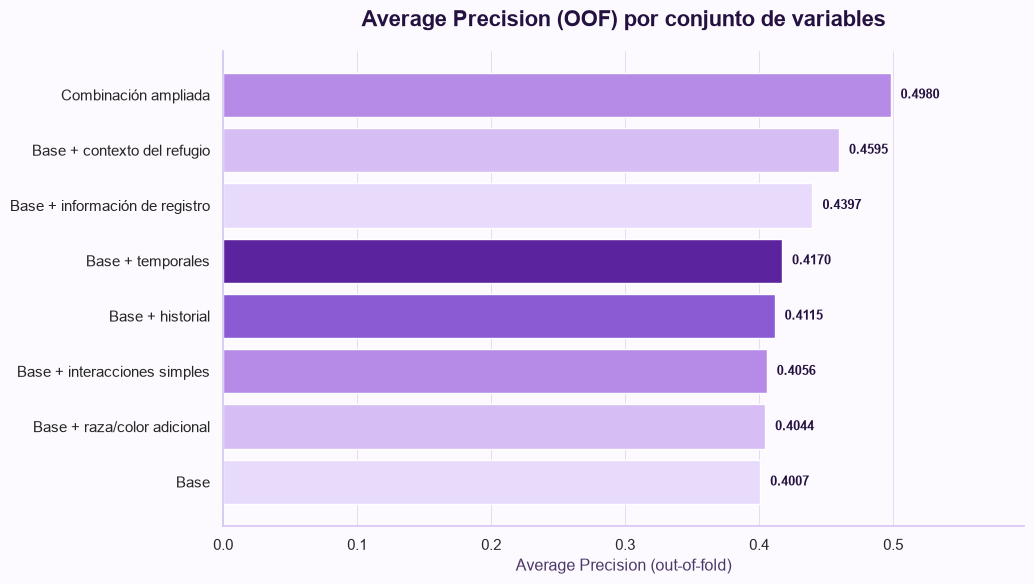

In [20]:
# Visualización comparativa de conjuntos de variables

fig, ax = plt.subplots(figsize=(10.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

datos_plot = resultados_grupos_variables_df.sort_values("average_precision", ascending=True)

colors = ["#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#5B239D"][:len(datos_plot)]

bars = ax.barh(
    datos_plot["conjunto_variables"],
    datos_plot["average_precision"],
    color=colors
)

ax.set_title(
    "Average Precision (OOF) por conjunto de variables",
    fontsize=16,
    fontweight="bold",
    color="#24113F",
    pad=18
)

ax.set_xlabel("Average Precision (out-of-fold)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("")

max_value = datos_plot["average_precision"].max()
ax.set_xlim(0, max_value * 1.2)

for bar, value in zip(bars, datos_plot["average_precision"]):
    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9.5,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.grid(axis="x", linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [21]:
# Selección del conjunto de variables ganador según Average Precision (OOF)

nombre_grupo_ganador = resultados_grupos_variables_df.iloc[0]["conjunto_variables"]
variables_finales = grupos_variables[nombre_grupo_ganador]

variables_numericas_finales, variables_categoricas_finales = clasificar_variables(
    variables_finales, dogs_model_dev
)

print("Conjunto de variables seleccionado:", nombre_grupo_ganador)
print("Número de variables:", len(variables_finales))
print("Variables:", variables_finales)

Conjunto de variables seleccionado: Combinación ampliada
Número de variables: 41
Variables: ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_months_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped', 'intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season', 'has_secondary_breed', 'secondary_breed', 'has_secondary_color', 'secondary_color', 'breed_num_terms', 'color_num_terms', 'has_name_intake', 'found_location_grouped', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count', 'n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d', 'age_group_intake_type', 'condition_intake_type', 'breed_age_group', 'season_condi

### 9.1. Interpretación de la comparación de conjuntos de variables

La comparación de conjuntos de variables permite comprobar si la ampliación del espacio predictivo mejora el `Average Precision` frente al conjunto base. Si la combinación ampliada supera claramente al punto de partida, se justifica avanzar con variables adicionales. Si alguna familia no aporta mejora, su utilidad se revisa posteriormente mediante el estudio de ablación.

## 10. Ajuste de hiperparámetros de CatBoost y LightGBM

A partir del conjunto de variables seleccionado inicialmente, se ajustan hiperparámetros de CatBoost y LightGBM mediante validación cruzada agrupada dentro del conjunto de desarrollo.

La búsqueda es deliberadamente moderada para equilibrar rendimiento y coste computacional. En ambos modelos se conserva `Average Precision` como criterio principal, ya que el objetivo es ordenar correctamente los perros con mayor riesgo de larga estancia.

In [22]:
# Preparación de los datos del conjunto de variables seleccionado

X_dev_final_catboost = preparar_datos_catboost(
    dogs_model_dev[variables_finales], variables_categoricas_finales
)

cat_features_finales = [
    X_dev_final_catboost.columns.get_loc(col) for col in variables_categoricas_finales
]

preprocesador_final_onehot = crear_preprocesador_onehot(
    variables_numericas_finales, variables_categoricas_finales
)

print("Variables numéricas finales:", variables_numericas_finales)
print("Variables categóricas finales:", variables_categoricas_finales)
print("Dimensiones de X_dev_final_catboost:", X_dev_final_catboost.shape)

Variables numéricas finales: ['age_months_intake', 'intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'has_secondary_breed', 'has_secondary_color', 'breed_num_terms', 'color_num_terms', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count', 'n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d']
Variables categóricas finales: ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped', 'intake_season', 'secondary_breed', 'secondary_color', 'has_name_intake', 'found_location_grouped', 'previous_outcome_type', 'age_group_intake_type', 'condition_intake_type', 'breed_age_group', 'season_condition']
Dimensiones de X_dev_fin

In [23]:
# Ajuste de hiperparámetros de CatBoost mediante validación cruzada agrupada (OOF)

parametros_catboost = {
    "iterations": [500, 700, 900],
    "learning_rate": [0.03, 0.04, 0.05, 0.08],
    "depth": [5, 6, 7],
    "l2_leaf_reg": [1, 3, 5, 7],
    "random_strength": [1, 2, 5],
    "auto_class_weights": [None, "Balanced"]
}

# Búsqueda moderada: amplía el entorno del mejor resultado observado sin disparar el coste computacional.
n_iter_catboost = 10

lista_parametros_catboost = list(ParameterSampler(
    parametros_catboost,
    n_iter=n_iter_catboost,
    random_state=RANDOM_STATE
))

resultados_busqueda_catboost = []
mejor_ap_catboost = -np.inf
mejores_parametros_catboost = None
mejor_oof_proba_catboost = None

inicio = time.time()

for i, parametros in enumerate(lista_parametros_catboost, start=1):
    print(f"CatBoost - combinación {i}/{n_iter_catboost}: {parametros}")

    parametros_modelo = {
        clave: valor
        for clave, valor in parametros.items()
        if valor is not None
    }

    modelo_cb = CatBoostClassifier(
        **parametros_modelo,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
        used_ram_limit="8gb"
    )

    oof_proba = generar_oof_proba(
        modelo_cb,
        X_dev_final_catboost,
        y_dev,
        groups=animal_id_dev,
        cv=cv_dev,
        fit_kwargs={"cat_features": cat_features_finales}
    )

    ap = average_precision_score(y_dev, oof_proba)
    roc_auc = roc_auc_score(y_dev, oof_proba)

    resultados_busqueda_catboost.append({
        "average_precision": ap,
        "roc_auc": roc_auc,
        **parametros
    })

    if ap > mejor_ap_catboost:
        mejor_ap_catboost = ap
        mejores_parametros_catboost = parametros_modelo
        mejor_oof_proba_catboost = oof_proba.copy()

    del modelo_cb, oof_proba
    gc.collect()

fin = time.time()

resultados_busqueda_catboost_df = pd.DataFrame(resultados_busqueda_catboost).sort_values(
    "average_precision", ascending=False
).reset_index(drop=True)

print(f"\nTiempo total CatBoost: {(fin - inicio) / 60:.2f} minutos")
print("Mejores hiperparámetros CatBoost:", mejores_parametros_catboost)
print("Mejor Average Precision (OOF):", round(mejor_ap_catboost, 4))

display(resultados_busqueda_catboost_df.round(4))

CatBoost - combinación 1/10: {'random_strength': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 700, 'depth': 6, 'auto_class_weights': None}
CatBoost - combinación 2/10: {'random_strength': 1, 'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 7, 'auto_class_weights': 'Balanced'}
CatBoost - combinación 3/10: {'random_strength': 5, 'learning_rate': 0.08, 'l2_leaf_reg': 1, 'iterations': 700, 'depth': 6, 'auto_class_weights': 'Balanced'}
CatBoost - combinación 4/10: {'random_strength': 1, 'learning_rate': 0.08, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 7, 'auto_class_weights': None}
CatBoost - combinación 5/10: {'random_strength': 5, 'learning_rate': 0.08, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 5, 'auto_class_weights': None}
CatBoost - combinación 6/10: {'random_strength': 5, 'learning_rate': 0.08, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 7, 'auto_class_weights': None}
CatBoost - combinación 7/10: {'random_strength': 5, 'learning_rate': 0.04, '

,average_precision,roc_auc,random_strength,learning_rate,l2_leaf_reg,iterations,depth,auto_class_weights
0,0.5128,0.8191,1,0.08,3,500,7,NaN
1,0.5119,0.8183,5,0.08,1,500,7,NaN
2,0.5107,0.8190,2,0.08,1,500,7,NaN
3,0.5074,0.8173,1,0.05,1,700,6,NaN
4,0.5019,0.8184,5,0.08,1,700,6,Balanced
5,0.4990,0.8137,5,0.08,3,500,5,NaN
6,0.4912,0.8149,1,0.03,1,500,7,Balanced
7,0.4884,0.8146,2,0.03,1,700,6,Balanced
8,0.4845,0.8133,5,0.04,1,700,5,Balanced
9,0.4819,0.8127,5,0.04,3,500,6,Balanced


In [24]:
# Ajuste de hiperparámetros de LightGBM mediante validación cruzada agrupada (OOF)

parametros_lgbm = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.08],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [20, 50, 80],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "class_weight": [None, "balanced"],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0, 1, 3]
}

n_iter_lgbm = 12

lista_parametros_lgbm = list(ParameterSampler(
    parametros_lgbm,
    n_iter=n_iter_lgbm,
    random_state=RANDOM_STATE
))

resultados_busqueda_lgbm = []
mejor_ap_lgbm = -np.inf
mejores_parametros_lgbm = None
mejor_oof_proba_lgbm = None

inicio = time.time()

for i, parametros in enumerate(lista_parametros_lgbm, start=1):
    print(f"LightGBM - combinación {i}/{n_iter_lgbm}: {parametros}")

    pipeline_lgbm_cv = Pipeline(steps=[
        ("preprocesador", crear_preprocesador_onehot(variables_numericas_finales, variables_categoricas_finales)),
        ("modelo", LGBMClassifier(
            **parametros,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    oof_proba = generar_oof_proba(
        pipeline_lgbm_cv,
        dogs_model_dev[variables_finales],
        y_dev,
        groups=animal_id_dev,
        cv=cv_dev
    )

    ap = average_precision_score(y_dev, oof_proba)
    roc_auc = roc_auc_score(y_dev, oof_proba)

    resultados_busqueda_lgbm.append({"average_precision": ap, "roc_auc": roc_auc, **parametros})

    if ap > mejor_ap_lgbm:
        mejor_ap_lgbm = ap
        mejores_parametros_lgbm = parametros
        mejor_oof_proba_lgbm = oof_proba.copy()

    del pipeline_lgbm_cv, oof_proba
    gc.collect()

fin = time.time()

resultados_busqueda_lgbm_df = pd.DataFrame(resultados_busqueda_lgbm).sort_values(
    "average_precision", ascending=False
).reset_index(drop=True)

print(f"\nTiempo total LightGBM: {(fin - inicio) / 60:.2f} minutos")
print("Mejores hiperparámetros LightGBM:", mejores_parametros_lgbm)
print("Mejor Average Precision (OOF):", round(mejor_ap_lgbm, 4))

display(resultados_busqueda_lgbm_df.round(4))

LightGBM - combinación 1/12: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 80, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'class_weight': 'balanced'}
LightGBM - combinación 2/12: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'class_weight': 'balanced'}
LightGBM - combinación 3/12: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 80, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8, 'class_weight': None}
LightGBM - combinación 4/12: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.9, 'class_weight': None}
LightGBM - combinación 5/12: {'subsample': 1.0, 'reg_lamb

,average_precision,roc_auc,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree,class_weight
0,0.5212,0.8220,0.8,1,0.1,31,700,50,-1,0.08,1.0,NaN
1,0.5209,0.8235,0.9,3,0.1,63,500,20,10,0.05,1.0,NaN
2,0.5181,0.8232,1.0,0,0.0,63,500,20,-1,0.03,1.0,balanced
3,0.5160,0.8218,0.9,3,0.1,63,300,20,-1,0.03,0.9,NaN
4,0.5123,0.8201,1.0,3,0.0,63,300,20,10,0.03,0.9,NaN
5,0.5072,0.8207,0.8,0,0.1,31,500,50,10,0.05,0.8,balanced
6,0.5058,0.8196,1.0,0,0.1,31,300,50,10,0.08,0.9,balanced
7,0.5047,0.8185,0.9,0,0.0,15,700,80,-1,0.05,0.9,NaN
8,0.4978,0.8183,1.0,1,0.1,31,500,50,-1,0.03,1.0,balanced
9,0.4916,0.8123,1.0,1,0.1,63,300,80,6,0.03,0.8,NaN


### 10.1. Interpretación del ajuste de hiperparámetros

Los resultados del ajuste permiten seleccionar una configuración competitiva para cada modelo sin consultar el conjunto de prueba. Las probabilidades *out-of-fold* de las mejores configuraciones se conservan para los análisis posteriores de cardinalidad, ablación, umbral y ensemble.

## 11. CatBoost: variables agrupadas frente a variables de mayor cardinalidad

CatBoost puede manejar variables categóricas de mayor cardinalidad de forma nativa. Por ello se compara una configuración con raza/color agrupados frente a otra que utiliza variables más detalladas de raza y color cuando están disponibles.

Además, se incorpora una tercera prueba específica de CatBoost con `found_location` completa. Esta variable no se utiliza de forma general en LightGBM por su alta cardinalidad, pero puede aportar señal adicional en CatBoost si la localización de entrada contiene patrones asociados a la probabilidad de larga estancia.

Todas estas pruebas se realizan únicamente dentro del conjunto de desarrollo y se incorporan después a la comparación integrada de candidatos finales.

In [25]:
# Comparación controlada: variables agrupadas frente a variables de mayor cardinalidad en CatBoost

variables_raza_color_completas = [
    "breed_intake" if "breed_intake" in dogs_model_ready.columns else "main_breed",
    "color_intake" if "color_intake" in dogs_model_ready.columns else "main_color"
]
variables_raza_color_completas = [v for v in variables_raza_color_completas if v in dogs_model_ready.columns]

variable_localizacion_completa = "found_location" if "found_location" in dogs_model_ready.columns else None


def aplicar_raza_color_completos(variables):
    """
    Sustituye las variables agrupadas de raza/color por sus equivalentes
    más detallados cuando están disponibles, manteniendo el resto de variables.
    """
    variables_sin_agrupadas = [
        var for var in variables
        if var not in [
            "main_breed_grouped", "main_color_grouped",
            "breed_intake", "color_intake", "main_breed", "main_color"
        ]
    ]
    return unir_variables_sin_duplicados(variables_sin_agrupadas, variables_raza_color_completas)


def aplicar_raza_color_y_localizacion_completos(variables):
    """
    Genera una alternativa específica para CatBoost con raza/color completos
    y localización original completa. Para evitar duplicidad excesiva, se
    reemplaza `found_location_grouped` por `found_location` cuando está disponible.
    """
    variables_completas = aplicar_raza_color_completos(variables)

    if variable_localizacion_completa is None:
        return variables_completas

    variables_sin_localizacion_agrupada = [
        var for var in variables_completas
        if var not in ["found_location_grouped", "found_location"]
    ]

    return unir_variables_sin_duplicados(
        variables_sin_localizacion_agrupada,
        [variable_localizacion_completa]
    )


def evaluar_catboost_oof(nombre_version, variables_version, oof_referencia=None):
    """
    Evalúa una configuración CatBoost mediante OOF. Si se proporciona una
    predicción de referencia, la reutiliza para evitar entrenamiento duplicado.
    """
    if oof_referencia is not None:
        oof_proba = oof_referencia
    else:
        _, variables_categoricas_version = clasificar_variables(variables_version, dogs_model_dev)

        X_dev_catboost_version = preparar_datos_catboost(
            dogs_model_dev[variables_version],
            variables_categoricas_version
        )

        cat_features_version = [
            X_dev_catboost_version.columns.get_loc(col)
            for col in variables_categoricas_version
        ]

        modelo_catboost_version = CatBoostClassifier(
            **mejores_parametros_catboost,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
            used_ram_limit="8gb"
        )

        oof_proba = generar_oof_proba(
            modelo_catboost_version,
            X_dev_catboost_version,
            y_dev,
            groups=animal_id_dev,
            cv=cv_dev,
            fit_kwargs={"cat_features": cat_features_version}
        )

        del modelo_catboost_version, X_dev_catboost_version
        gc.collect()

    return {
        "version_categorica": nombre_version,
        "numero_variables": len(variables_version),
        "average_precision_oof": average_precision_score(y_dev, oof_proba),
        "roc_auc_oof": roc_auc_score(y_dev, oof_proba),
        "variables": variables_version,
        "oof_proba": oof_proba
    }


variables_finales_cardinalidad_alta = aplicar_raza_color_completos(variables_finales)
variables_finales_cardinalidad_alta_localizacion = aplicar_raza_color_y_localizacion_completos(variables_finales)

resultados_cardinalidad_catboost = []

resultado_cardinalidad_agrupada = evaluar_catboost_oof(
    "Raza/color agrupados",
    variables_finales,
    oof_referencia=mejor_oof_proba_catboost
)
resultados_cardinalidad_catboost.append(resultado_cardinalidad_agrupada)

resultado_cardinalidad_alta = evaluar_catboost_oof(
    "Raza/color completos",
    variables_finales_cardinalidad_alta
)
resultados_cardinalidad_catboost.append(resultado_cardinalidad_alta)

oof_proba_catboost_cardinalidad_alta = resultado_cardinalidad_alta["oof_proba"]
ap_cardinalidad_alta = resultado_cardinalidad_alta["average_precision_oof"]
ap_cardinalidad_agrupada = resultado_cardinalidad_agrupada["average_precision_oof"]

if variable_localizacion_completa is not None:
    if set(variables_finales_cardinalidad_alta_localizacion) == set(variables_finales_cardinalidad_alta):
        resultado_cardinalidad_alta_localizacion = resultado_cardinalidad_alta
    else:
        resultado_cardinalidad_alta_localizacion = evaluar_catboost_oof(
            "Raza/color completos + localización completa",
            variables_finales_cardinalidad_alta_localizacion
        )

    resultados_cardinalidad_catboost.append(resultado_cardinalidad_alta_localizacion)
    oof_proba_catboost_cardinalidad_alta_localizacion = resultado_cardinalidad_alta_localizacion["oof_proba"]
    ap_cardinalidad_alta_localizacion = resultado_cardinalidad_alta_localizacion["average_precision_oof"]
else:
    oof_proba_catboost_cardinalidad_alta_localizacion = None
    ap_cardinalidad_alta_localizacion = np.nan

comparacion_cardinalidad = pd.DataFrame([
    {k: v for k, v in resultado.items() if k not in ["variables", "oof_proba"]}
    for resultado in resultados_cardinalidad_catboost
]).sort_values("average_precision_oof", ascending=False).reset_index(drop=True)

display(comparacion_cardinalidad.round(4))

mejor_resultado_cardinalidad = max(
    resultados_cardinalidad_catboost,
    key=lambda x: x["average_precision_oof"]
)

print("Mejor alternativa CatBoost en esta comparación:", mejor_resultado_cardinalidad["version_categorica"])
print("Average Precision OOF:", round(mejor_resultado_cardinalidad["average_precision_oof"], 4))
print("ROC-AUC OOF:", round(mejor_resultado_cardinalidad["roc_auc_oof"], 4))

,version_categorica,numero_variables,average_precision_oof,roc_auc_oof
0,Raza/color completos + localización completa,41,0.5533,0.8415
1,Raza/color completos,41,0.5319,0.8312
2,Raza/color agrupados,41,0.5128,0.8191


Mejor alternativa CatBoost en esta comparación: Raza/color completos + localización completa
Average Precision OOF: 0.5533
ROC-AUC OOF: 0.8415


### 11.1. Interpretación de la comparación de cardinalidad

La comparación de cardinalidad indica si CatBoost obtiene mayor capacidad de ordenación al utilizar información más detallada de raza, color y localización de entrada. Estas variables no se incorporan automáticamente al modelo final: se conservan como candidatos y se comparan de nuevo con el resto de alternativas después del estudio de ablación.

De esta forma, la decisión final prioriza rendimiento `Average Precision` *out-of-fold* sin introducir variables de alta cardinalidad en modelos que no están diseñados para gestionarlas de forma nativa.

## 12. Estudio de ablación de variables

El estudio de ablación analiza de forma más precisa qué familias de variables aportan rendimiento. Se realizan dos enfoques complementarios:

- **Ablación incremental**: parte del conjunto base y añade familias de variables.
- **Ablación inversa**: parte del conjunto completo y elimina una familia cada vez.

Todos los experimentos se evalúan con los mismos folds y con la configuración de CatBoost seleccionada previamente. Esto permite comparar el efecto relativo de cada familia de variables de forma más controlada.

In [26]:
# Familias de variables para el estudio de ablación

familia_temporales = candidatas_temporales_disponibles
familia_raza_color = candidatas_raza_color_disponibles
familia_registro = candidatas_registro_disponibles
familia_historial = candidatas_historial_disponibles
familia_contexto_refugio = candidatas_contexto_refugio_disponibles
familia_interacciones = candidatas_interacciones_disponibles

familias_ablacion = {
    "Base": variables_base,
    "Temporales": familia_temporales,
    "Raza/color adicional": familia_raza_color,
    "Información de registro": familia_registro,
    "Historial": familia_historial,
    "Contexto del refugio": familia_contexto_refugio,
    "Interacciones simples": familia_interacciones
}

for nombre_familia, variables_familia in familias_ablacion.items():
    print(f"{nombre_familia}: {len(variables_familia)} variables -> {variables_familia}")

Base: 9 variables -> ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_months_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped']
Temporales: 5 variables -> ['intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season']
Raza/color adicional: 6 variables -> ['has_secondary_breed', 'secondary_breed', 'has_secondary_color', 'secondary_color', 'breed_num_terms', 'color_num_terms']
Información de registro: 2 variables -> ['has_name_intake', 'found_location_grouped']
Historial: 8 variables -> ['previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count']
Contexto del refugio: 7 variables -> ['n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_inta

In [27]:
# Función auxiliar y folds fijos para el estudio de ablación

folds_ablacion = list(cv_dev.split(dogs_model_dev, y_dev, animal_id_dev))

print("Número de folds utilizados en la ablación:", len(folds_ablacion))


def evaluar_variables_catboost_oof(variables, folds=folds_ablacion):
    """
    Evalúa un conjunto de variables predictoras con CatBoost, utilizando la
    configuración de hiperparámetros ya seleccionada en el apartado 10 y
    exactamente los mismos folds en todos los experimentos. Devuelve las
    probabilidades out-of-fold y la lista de Average Precision por fold.
    """
    _, variables_categoricas_exp = clasificar_variables(variables, dogs_model_dev)
    X_exp = preparar_datos_catboost(dogs_model_dev[variables], variables_categoricas_exp)
    cat_features_exp = [X_exp.columns.get_loc(col) for col in variables_categoricas_exp]

    oof_proba = np.full(len(X_exp), np.nan)
    ap_por_fold = []

    for idx_train, idx_val in folds:
        modelo_fold = CatBoostClassifier(
            **mejores_parametros_catboost,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
            used_ram_limit="8gb"
        )

        modelo_fold.fit(
            X_exp.iloc[idx_train],
            y_dev.iloc[idx_train],
            cat_features=cat_features_exp
        )

        proba_val = modelo_fold.predict_proba(X_exp.iloc[idx_val])[:, 1]
        oof_proba[idx_val] = proba_val.astype(np.float32)
        ap_por_fold.append(average_precision_score(y_dev.iloc[idx_val], proba_val))

        del modelo_fold, proba_val
        gc.collect()

    del X_exp
    gc.collect()

    return oof_proba, ap_por_fold


def resumir_experimento_ablacion(nombre_experimento, variables, familias_incorporadas):
    """Evalúa un experimento de ablación y devuelve su fila de resumen junto
    con las probabilidades OOF, para poder reutilizarlas si hiciera falta."""
    oof_proba, ap_por_fold = evaluar_variables_catboost_oof(variables)

    resumen = {
        "experimento": nombre_experimento,
        "num_variables": len(variables),
        "average_precision_oof": average_precision_score(y_dev, oof_proba),
        "roc_auc_oof": roc_auc_score(y_dev, oof_proba),
        "average_precision_media_folds": np.mean(ap_por_fold),
        "average_precision_std_folds": np.std(ap_por_fold),
        "familias_incorporadas": familias_incorporadas
    }

    return resumen, oof_proba


columnas_ablacion = [
    "experimento", "num_variables", "average_precision_oof", "roc_auc_oof",
    "average_precision_media_folds", "average_precision_std_folds", "familias_incorporadas"
]

columnas_redondeo_ablacion = [
    "average_precision_oof", "roc_auc_oof", "average_precision_media_folds", "average_precision_std_folds"
]

Número de folds utilizados en la ablación: 5


In [28]:
# Primera parte: ablación incremental

experimentos_incrementales = {
    "Base": (
        variables_base,
        "Base"
    ),
    "Base + temporales": (
        unir_variables_sin_duplicados(variables_base, familia_temporales),
        "Base, Temporales"
    ),
    "Base + raza/color adicional": (
        unir_variables_sin_duplicados(variables_base, familia_raza_color),
        "Base, Raza/color adicional"
    ),
    "Base + información de registro": (
        unir_variables_sin_duplicados(variables_base, familia_registro),
        "Base, Información de registro"
    ),
    "Base + historial": (
        unir_variables_sin_duplicados(variables_base, familia_historial),
        "Base, Historial"
    ),
    "Base + contexto del refugio": (
        unir_variables_sin_duplicados(variables_base, familia_contexto_refugio),
        "Base, Contexto del refugio"
    ),
    "Base + interacciones simples": (
        unir_variables_sin_duplicados(variables_base, familia_interacciones),
        "Base, Interacciones simples"
    ),
    "Todas": (
        unir_variables_sin_duplicados(
            variables_base,
            familia_temporales,
            familia_raza_color,
            familia_registro,
            familia_historial,
            familia_contexto_refugio,
            familia_interacciones
        ),
        "Base, Temporales, Raza/color adicional, Información de registro, Historial, Contexto del refugio, Interacciones simples"
    )
}

resultados_ablacion_incremental = []
oof_proba_ablacion = {}

for nombre_experimento, (variables_experimento, familias_incorporadas) in experimentos_incrementales.items():
    print(f"Evaluando (ablación incremental): {nombre_experimento}")
    resumen, oof_proba = resumir_experimento_ablacion(nombre_experimento, variables_experimento, familias_incorporadas)
    resultados_ablacion_incremental.append(resumen)
    oof_proba_ablacion[nombre_experimento] = oof_proba

resultados_ablacion_incremental_df = pd.DataFrame(resultados_ablacion_incremental)[columnas_ablacion]
resultados_ablacion_incremental_df[columnas_redondeo_ablacion] = (
    resultados_ablacion_incremental_df[columnas_redondeo_ablacion].round(4)
)

resultados_ablacion_incremental_df = resultados_ablacion_incremental_df.sort_values(
    "average_precision_oof", ascending=False
).reset_index(drop=True)

display(resultados_ablacion_incremental_df)

Evaluando (ablación incremental): Base
Evaluando (ablación incremental): Base + temporales
Evaluando (ablación incremental): Base + raza/color adicional
Evaluando (ablación incremental): Base + información de registro
Evaluando (ablación incremental): Base + historial
Evaluando (ablación incremental): Base + contexto del refugio
Evaluando (ablación incremental): Base + interacciones simples
Evaluando (ablación incremental): Todas


,experimento,num_variables,average_precision_oof,roc_auc_oof,average_precision_media_folds,average_precision_std_folds,familias_incorporadas
0,Todas,41,0.5128,0.8191,0.5131,0.0095,"Base, Temporales, Raza/color adicional, Inform..."
1,Base + contexto del refugio,16,0.4759,0.7940,0.4761,0.0093,"Base, Contexto del refugio"
2,Base + información de registro,11,0.4476,0.7833,0.4479,0.0057,"Base, Información de registro"
3,Base + temporales,14,0.4313,0.7600,0.4316,0.0060,"Base, Temporales"
4,Base + historial,17,0.4196,0.7635,0.4200,0.0068,"Base, Historial"
5,Base + raza/color adicional,15,0.4184,0.7630,0.4188,0.0046,"Base, Raza/color adicional"
6,Base + interacciones simples,13,0.4172,0.7592,0.4175,0.0042,"Base, Interacciones simples"
7,Base,9,0.4105,0.7574,0.4108,0.0047,Base


In [29]:
# Segunda parte: ablación inversa

variables_todas_ablacion = experimentos_incrementales["Todas"][0]

experimentos_inversos = {
    "Todas": (
        variables_todas_ablacion,
        "Base, Temporales, Raza/color adicional, Información de registro, Historial, Contexto del refugio, Interacciones simples"
    ),
    "Todas menos temporales": (
        [v for v in variables_todas_ablacion if v not in familia_temporales],
        "Base, Raza/color adicional, Información de registro, Historial, Contexto del refugio, Interacciones simples"
    ),
    "Todas menos raza/color adicional": (
        [v for v in variables_todas_ablacion if v not in familia_raza_color],
        "Base, Temporales, Información de registro, Historial, Contexto del refugio, Interacciones simples"
    ),
    "Todas menos información de registro": (
        [v for v in variables_todas_ablacion if v not in familia_registro],
        "Base, Temporales, Raza/color adicional, Historial, Contexto del refugio, Interacciones simples"
    ),
    "Todas menos historial": (
        [v for v in variables_todas_ablacion if v not in familia_historial],
        "Base, Temporales, Raza/color adicional, Información de registro, Contexto del refugio, Interacciones simples"
    ),
    "Todas menos contexto del refugio": (
        [v for v in variables_todas_ablacion if v not in familia_contexto_refugio],
        "Base, Temporales, Raza/color adicional, Información de registro, Historial, Interacciones simples"
    ),
    "Todas menos interacciones simples": (
        [v for v in variables_todas_ablacion if v not in familia_interacciones],
        "Base, Temporales, Raza/color adicional, Información de registro, Historial, Contexto del refugio"
    )
}

resultados_ablacion_inversa = []

for nombre_experimento, (variables_experimento, familias_incorporadas) in experimentos_inversos.items():
    if nombre_experimento in oof_proba_ablacion:
        oof_proba = oof_proba_ablacion[nombre_experimento]
        ap_por_fold = [
            average_precision_score(y_dev.iloc[idx_val], oof_proba[idx_val])
            for _, idx_val in folds_ablacion
        ]
        resumen = {
            "experimento": nombre_experimento,
            "num_variables": len(variables_experimento),
            "average_precision_oof": average_precision_score(y_dev, oof_proba),
            "roc_auc_oof": roc_auc_score(y_dev, oof_proba),
            "average_precision_media_folds": np.mean(ap_por_fold),
            "average_precision_std_folds": np.std(ap_por_fold),
            "familias_incorporadas": familias_incorporadas
        }
    else:
        print(f"Evaluando (ablación inversa): {nombre_experimento}")
        resumen, oof_proba = resumir_experimento_ablacion(nombre_experimento, variables_experimento, familias_incorporadas)
        oof_proba_ablacion[nombre_experimento] = oof_proba

    resultados_ablacion_inversa.append(resumen)

resultados_ablacion_inversa_df = pd.DataFrame(resultados_ablacion_inversa)[columnas_ablacion]
resultados_ablacion_inversa_df[columnas_redondeo_ablacion] = (
    resultados_ablacion_inversa_df[columnas_redondeo_ablacion].round(4)
)

resultados_ablacion_inversa_df = resultados_ablacion_inversa_df.sort_values(
    "average_precision_oof", ascending=False
).reset_index(drop=True)

display(resultados_ablacion_inversa_df)

Evaluando (ablación inversa): Todas menos temporales
Evaluando (ablación inversa): Todas menos raza/color adicional
Evaluando (ablación inversa): Todas menos información de registro
Evaluando (ablación inversa): Todas menos historial
Evaluando (ablación inversa): Todas menos contexto del refugio
Evaluando (ablación inversa): Todas menos interacciones simples


,experimento,num_variables,average_precision_oof,roc_auc_oof,average_precision_media_folds,average_precision_std_folds,familias_incorporadas
0,Todas menos interacciones simples,37,0.5132,0.8191,0.5136,0.0108,"Base, Temporales, Raza/color adicional, Inform..."
1,Todas,41,0.5128,0.8191,0.5131,0.0095,"Base, Temporales, Raza/color adicional, Inform..."
2,Todas menos temporales,36,0.5098,0.8192,0.5101,0.0105,"Base, Raza/color adicional, Información de reg..."
3,Todas menos raza/color adicional,35,0.5079,0.8169,0.5082,0.0080,"Base, Temporales, Información de registro, His..."
4,Todas menos historial,33,0.5055,0.8159,0.5058,0.0076,"Base, Temporales, Raza/color adicional, Inform..."
5,Todas menos información de registro,39,0.4878,0.8012,0.4879,0.0114,"Base, Temporales, Raza/color adicional, Histor..."
6,Todas menos contexto del refugio,34,0.4730,0.7961,0.4734,0.0074,"Base, Temporales, Raza/color adicional, Inform..."


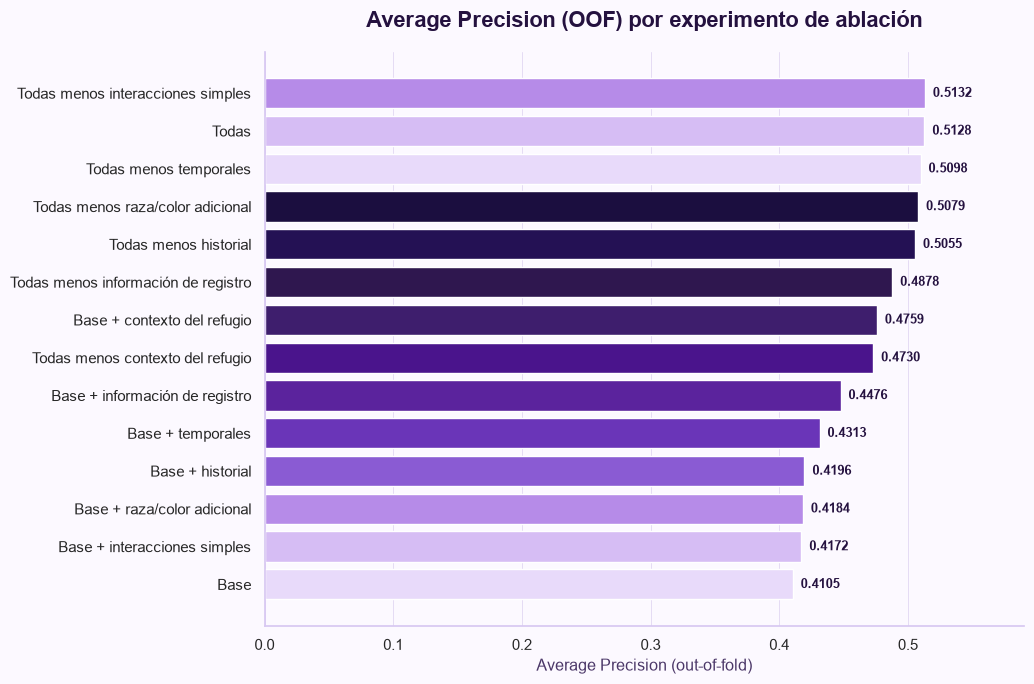

In [30]:
# Visualización de la ablación: Average Precision OOF por experimento

tabla_ablacion_completa = pd.concat([
    resultados_ablacion_incremental_df,
    resultados_ablacion_inversa_df[resultados_ablacion_inversa_df["experimento"] != "Todas"]
], ignore_index=True)

datos_plot_ablacion = tabla_ablacion_completa.sort_values("average_precision_oof", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

colors_ablacion = [
    "#E8DAFA", "#D6BDF4", "#B68BE8", "#8A5BD3", "#6A35B8",
    "#5B239D", "#4A148C", "#3E1E6D", "#2F174F", "#241154", "#1B0E3F"
][:len(datos_plot_ablacion)]

bars = ax.barh(
    datos_plot_ablacion["experimento"],
    datos_plot_ablacion["average_precision_oof"],
    color=colors_ablacion
)

ax.set_title(
    "Average Precision (OOF) por experimento de ablación",
    fontsize=16,
    fontweight="bold",
    color="#24113F",
    pad=18
)

ax.set_xlabel("Average Precision (out-of-fold)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("")

max_value_ablacion = datos_plot_ablacion["average_precision_oof"].max()
ax.set_xlim(0, max_value_ablacion * 1.15)

for bar, value in zip(bars, datos_plot_ablacion["average_precision_oof"]):
    ax.text(
        value + max_value_ablacion * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9,
        color="#24113F",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")

ax.grid(axis="x", linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [31]:
# Selección del conjunto de variables final tras la ablación

tabla_ablacion_completa = tabla_ablacion_completa.sort_values(
    ["average_precision_oof", "num_variables"],
    ascending=[False, True]
).reset_index(drop=True)

mejor_experimento_ablacion = tabla_ablacion_completa.iloc[0]

margen_equivalencia_ablacion = mejor_experimento_ablacion["average_precision_std_folds"]

candidatos_equivalentes_ablacion = tabla_ablacion_completa[
    tabla_ablacion_completa["average_precision_oof"]
    >= mejor_experimento_ablacion["average_precision_oof"] - margen_equivalencia_ablacion
].sort_values(["average_precision_oof", "num_variables"], ascending=[False, True])

print("Mejor experimento por Average Precision OOF:", mejor_experimento_ablacion["experimento"])
print("Margen informativo de equivalencia:", round(margen_equivalencia_ablacion, 4))
print("\nExperimentos dentro del margen informativo de equivalencia:")
display(candidatos_equivalentes_ablacion[columnas_ablacion])

# Para maximizar rendimiento predictivo, la selección operativa se realiza por
# Average Precision OOF. La simplicidad se conserva como criterio interpretativo,
# pero no reemplaza al mejor resultado cuando el objetivo es rendimiento.
experimento_seleccionado_ablacion = mejor_experimento_ablacion

todos_los_experimentos_ablacion = {**experimentos_incrementales, **experimentos_inversos}
variables_predictoras_finales = todos_los_experimentos_ablacion[
    experimento_seleccionado_ablacion["experimento"]
][0]

print("\nExperimento seleccionado para rendimiento:", experimento_seleccionado_ablacion["experimento"])
print("variables_predictoras_finales:", variables_predictoras_finales)
print("Número de variables seleccionadas:", len(variables_predictoras_finales))

Mejor experimento por Average Precision OOF: Todas menos interacciones simples
Margen informativo de equivalencia: 0.0108

Experimentos dentro del margen informativo de equivalencia:


,experimento,num_variables,average_precision_oof,roc_auc_oof,average_precision_media_folds,average_precision_std_folds,familias_incorporadas
0,Todas menos interacciones simples,37,0.5132,0.8191,0.5136,0.0108,"Base, Temporales, Raza/color adicional, Inform..."
1,Todas,41,0.5128,0.8191,0.5131,0.0095,"Base, Temporales, Raza/color adicional, Inform..."
2,Todas menos temporales,36,0.5098,0.8192,0.5101,0.0105,"Base, Raza/color adicional, Información de reg..."
3,Todas menos raza/color adicional,35,0.5079,0.8169,0.5082,0.0080,"Base, Temporales, Información de registro, His..."
4,Todas menos historial,33,0.5055,0.8159,0.5058,0.0076,"Base, Temporales, Raza/color adicional, Inform..."



Experimento seleccionado para rendimiento: Todas menos interacciones simples
variables_predictoras_finales: ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_months_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped', 'intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season', 'has_secondary_breed', 'secondary_breed', 'has_secondary_color', 'secondary_color', 'breed_num_terms', 'color_num_terms', 'has_name_intake', 'found_location_grouped', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count', 'n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d']
Número de variables seleccionadas: 37


In [32]:
# Selección integrada de candidatos finales tras ablación y cardinalidad

variables_lgbm_pre_ablacion = list(variables_finales)
variables_catboost_pre_ablacion_agrupadas = list(variables_lgbm_pre_ablacion)
variables_catboost_pre_ablacion_completas = list(variables_finales_cardinalidad_alta)
variables_catboost_pre_ablacion_completas_localizacion = list(variables_finales_cardinalidad_alta_localizacion)


def resumen_oof_candidato(nombre, familia_modelo, variables, oof_proba):
    return {
        "candidato": nombre,
        "familia_modelo": familia_modelo,
        "num_variables": len(variables),
        "average_precision_oof": average_precision_score(y_dev, oof_proba),
        "roc_auc_oof": roc_auc_score(y_dev, oof_proba),
        "variables": variables,
        "oof_proba": oof_proba
    }


def evaluar_catboost_variables(variables_catboost, nombre_candidato):
    """Evalúa mediante OOF un conjunto concreto de variables para CatBoost."""
    _, variables_categoricas_catboost = clasificar_variables(variables_catboost, dogs_model_dev)

    X_dev_catboost = preparar_datos_catboost(
        dogs_model_dev[variables_catboost],
        variables_categoricas_catboost
    )

    cat_features_catboost = [
        X_dev_catboost.columns.get_loc(col)
        for col in variables_categoricas_catboost
    ]

    modelo_catboost = CatBoostClassifier(
        **mejores_parametros_catboost,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
        used_ram_limit="8gb"
    )

    print(f"Se evalúa {nombre_candidato}.")

    oof_proba = generar_oof_proba(
        modelo_catboost,
        X_dev_catboost,
        y_dev,
        groups=animal_id_dev,
        cv=cv_dev,
        fit_kwargs={"cat_features": cat_features_catboost}
    )

    del modelo_catboost, X_dev_catboost
    gc.collect()

    return oof_proba


# Candidatos LightGBM: se compara el conjunto ampliado preliminar con el conjunto
# seleccionado por ablación. Esto evita perder rendimiento si la ablación favorece
# una configuración distinta a la usada durante la búsqueda de hiperparámetros.
candidatos_lgbm = [
    resumen_oof_candidato(
        "LightGBM - combinación ampliada",
        "LightGBM",
        variables_lgbm_pre_ablacion,
        mejor_oof_proba_lgbm
    )
]

if set(variables_predictoras_finales) != set(variables_lgbm_pre_ablacion):
    print("Se recalcula LightGBM con el conjunto seleccionado por ablación.")

    variables_numericas_ablacion_lgbm, variables_categoricas_ablacion_lgbm = clasificar_variables(
        variables_predictoras_finales, dogs_model_dev
    )

    pipeline_lgbm_ablacion = Pipeline(steps=[
        ("preprocesador", crear_preprocesador_onehot(
            variables_numericas_ablacion_lgbm,
            variables_categoricas_ablacion_lgbm
        )),
        ("modelo", LGBMClassifier(
            **mejores_parametros_lgbm,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    oof_proba_lgbm_ablacion = generar_oof_proba(
        pipeline_lgbm_ablacion,
        dogs_model_dev[variables_predictoras_finales],
        y_dev,
        groups=animal_id_dev,
        cv=cv_dev
    )

    candidatos_lgbm.append(
        resumen_oof_candidato(
            "LightGBM - conjunto seleccionado por ablación",
            "LightGBM",
            variables_predictoras_finales,
            oof_proba_lgbm_ablacion
        )
    )

    del pipeline_lgbm_ablacion
    gc.collect()


# Candidatos CatBoost: se comparan las alternativas agrupadas, con raza/color
# completos y con localización completa cuando está disponible. La decisión final
# se toma por rendimiento OOF, no por preferencia previa de simplicidad.
candidatos_catboost = [
    resumen_oof_candidato(
        "CatBoost - combinación ampliada agrupada",
        "CatBoost",
        variables_catboost_pre_ablacion_agrupadas,
        mejor_oof_proba_catboost
    ),
    resumen_oof_candidato(
        "CatBoost - combinación ampliada con raza/color completos",
        "CatBoost",
        variables_catboost_pre_ablacion_completas,
        oof_proba_catboost_cardinalidad_alta
    )
]

if oof_proba_catboost_cardinalidad_alta_localizacion is not None:
    candidatos_catboost.append(
        resumen_oof_candidato(
            "CatBoost - combinación ampliada con raza/color completos y localización completa",
            "CatBoost",
            variables_catboost_pre_ablacion_completas_localizacion,
            oof_proba_catboost_cardinalidad_alta_localizacion
        )
    )

candidatos_catboost.append(
    resumen_oof_candidato(
        "CatBoost - conjunto seleccionado por ablación agrupado",
        "CatBoost",
        variables_predictoras_finales,
        oof_proba_ablacion[experimento_seleccionado_ablacion["experimento"]]
    )
)

variables_catboost_ablacion_completas = aplicar_raza_color_completos(variables_predictoras_finales)

if set(variables_catboost_ablacion_completas) != set(variables_predictoras_finales):
    if set(variables_catboost_ablacion_completas) == set(variables_catboost_pre_ablacion_completas):
        oof_proba_catboost_ablacion_completas = oof_proba_catboost_cardinalidad_alta
    else:
        oof_proba_catboost_ablacion_completas = evaluar_catboost_variables(
            variables_catboost_ablacion_completas,
            "CatBoost con conjunto de ablación y raza/color completos"
        )

    candidatos_catboost.append(
        resumen_oof_candidato(
            "CatBoost - conjunto seleccionado por ablación con raza/color completos",
            "CatBoost",
            variables_catboost_ablacion_completas,
            oof_proba_catboost_ablacion_completas
        )
    )

variables_catboost_ablacion_completas_localizacion = aplicar_raza_color_y_localizacion_completos(
    variables_predictoras_finales
)

if variable_localizacion_completa is not None and set(variables_catboost_ablacion_completas_localizacion) != set(variables_catboost_ablacion_completas):
    if set(variables_catboost_ablacion_completas_localizacion) == set(variables_catboost_pre_ablacion_completas_localizacion):
        oof_proba_catboost_ablacion_completas_localizacion = oof_proba_catboost_cardinalidad_alta_localizacion
    else:
        oof_proba_catboost_ablacion_completas_localizacion = evaluar_catboost_variables(
            variables_catboost_ablacion_completas_localizacion,
            "CatBoost con conjunto de ablación, raza/color completos y localización completa"
        )

    candidatos_catboost.append(
        resumen_oof_candidato(
            "CatBoost - conjunto seleccionado por ablación con raza/color completos y localización completa",
            "CatBoost",
            variables_catboost_ablacion_completas_localizacion,
            oof_proba_catboost_ablacion_completas_localizacion
        )
    )


# Tablas comparativas sin las columnas de arrays/listas para facilitar lectura.
tabla_candidatos_lgbm = pd.DataFrame([
    {k: v for k, v in candidato.items() if k not in ["variables", "oof_proba"]}
    for candidato in candidatos_lgbm
]).sort_values("average_precision_oof", ascending=False).reset_index(drop=True)

tabla_candidatos_catboost = pd.DataFrame([
    {k: v for k, v in candidato.items() if k not in ["variables", "oof_proba"]}
    for candidato in candidatos_catboost
]).sort_values("average_precision_oof", ascending=False).reset_index(drop=True)

print("Candidatos LightGBM:")
display(tabla_candidatos_lgbm.round(4))

print("Candidatos CatBoost:")
display(tabla_candidatos_catboost.round(4))

mejor_candidato_lgbm = max(candidatos_lgbm, key=lambda x: x["average_precision_oof"])
mejor_candidato_catboost = max(candidatos_catboost, key=lambda x: x["average_precision_oof"])

variables_finales = mejor_candidato_lgbm["variables"]
mejor_oof_proba_lgbm = mejor_candidato_lgbm["oof_proba"]

variables_finales_catboost = mejor_candidato_catboost["variables"]
oof_proba_catboost_final = mejor_candidato_catboost["oof_proba"]

variables_numericas_finales, variables_categoricas_finales = clasificar_variables(
    variables_finales, dogs_model_dev
)

print("Candidato LightGBM seleccionado:", mejor_candidato_lgbm["candidato"])
print("Variables finales LightGBM:", variables_finales)

print("\nCandidato CatBoost seleccionado:", mejor_candidato_catboost["candidato"])
print("Variables finales CatBoost:", variables_finales_catboost)

Se recalcula LightGBM con el conjunto seleccionado por ablación.
Se evalúa CatBoost con conjunto de ablación y raza/color completos.
Se evalúa CatBoost con conjunto de ablación, raza/color completos y localización completa.
Candidatos LightGBM:


,candidato,familia_modelo,num_variables,average_precision_oof,roc_auc_oof
0,LightGBM - conjunto seleccionado por ablación,LightGBM,37,0.5246,0.8227
1,LightGBM - combinación ampliada,LightGBM,41,0.5212,0.8220


Candidatos CatBoost:


,candidato,familia_modelo,num_variables,average_precision_oof,roc_auc_oof
0,CatBoost - combinación ampliada con raza/color...,CatBoost,41,0.5533,0.8415
1,CatBoost - conjunto seleccionado por ablación ...,CatBoost,37,0.5526,0.8406
2,CatBoost - combinación ampliada con raza/color...,CatBoost,41,0.5319,0.8312
3,CatBoost - conjunto seleccionado por ablación ...,CatBoost,37,0.5301,0.8294
4,CatBoost - conjunto seleccionado por ablación ...,CatBoost,37,0.5132,0.8191
5,CatBoost - combinación ampliada agrupada,CatBoost,41,0.5128,0.8191


Candidato LightGBM seleccionado: LightGBM - conjunto seleccionado por ablación
Variables finales LightGBM: ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_months_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped', 'intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season', 'has_secondary_breed', 'secondary_breed', 'has_secondary_color', 'secondary_color', 'breed_num_terms', 'color_num_terms', 'has_name_intake', 'found_location_grouped', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previous_stay_days', 'previous_long_stay_count', 'previous_owner_surrender_count', 'previous_stray_count', 'n_intakes_dogs_last_7d', 'n_intakes_dogs_last_30d', 'n_outcomes_dogs_last_7d', 'n_outcomes_dogs_last_30d', 'n_adoptions_dogs_last_30d', 'estimated_active_dogs_at_intake', 'ratio_intakes_outcomes_30d']

Candidato CatBoost seleccionado: CatBoost - combinación ampliada c

### 12.1. Interpretación del estudio de ablación

La ablación permite identificar si la mejora del modelo procede de variables temporales, historial, contexto del refugio, raza/color, información de registro o interacciones simples. La selección operativa prioriza `Average Precision` *out-of-fold* para maximizar rendimiento, mientras que la simplicidad se mantiene como criterio interpretativo secundario.

## 13. Selección del umbral de decisión

Hasta este punto, la selección de variables, hiperparámetros y candidatos se ha basado principalmente en `Average Precision`, una métrica independiente del umbral de clasificación.

En este apartado se calcula el umbral que maximiza el `F1-score` sobre las probabilidades *out-of-fold* de CatBoost y LightGBM por separado. Estos umbrales sirven como referencia para comparar los modelos individuales. La decisión definitiva del ensemble se realiza después mediante una búsqueda conjunta de peso y umbral dentro del conjunto de desarrollo.

In [33]:
# Selección del umbral de decisión mediante validación cruzada agrupada (OOF)

umbral_catboost, tabla_umbrales_catboost = buscar_mejor_umbral(y_dev, oof_proba_catboost_final)
umbral_lgbm, tabla_umbrales_lgbm = buscar_mejor_umbral(y_dev, mejor_oof_proba_lgbm)

metricas_catboost_oof = calcular_metricas_proba(y_dev, oof_proba_catboost_final, umbral=umbral_catboost)
metricas_lgbm_oof = calcular_metricas_proba(y_dev, mejor_oof_proba_lgbm, umbral=umbral_lgbm)

resumen_umbrales = pd.DataFrame([
    {"modelo": "CatBoost", "umbral_optimo": umbral_catboost, **metricas_catboost_oof},
    {"modelo": "LightGBM", "umbral_optimo": umbral_lgbm, **metricas_lgbm_oof}
])

columnas_resumen = ["modelo", "umbral_optimo", "accuracy", "precision", "recall", "f1_score", "roc_auc", "average_precision"]
resumen_umbrales = resumen_umbrales[columnas_resumen]
resumen_umbrales[columnas_resumen[1:]] = resumen_umbrales[columnas_resumen[1:]].round(4)

display(resumen_umbrales)

,modelo,umbral_optimo,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,CatBoost,0.25,0.8213,0.462,0.6245,0.5311,0.8415,0.5533
1,LightGBM,0.23,0.8012,0.423,0.6232,0.5039,0.8227,0.5246


### 13.1. Interpretación de la selección de umbral

La tabla anterior muestra, para CatBoost y LightGBM, el umbral que maximiza el `F1-score` sobre las probabilidades *out-of-fold*, junto con el resto de métricas evaluadas en ese umbral.

`Average Precision` y `ROC-AUC` dependen de la ordenación de las probabilidades y no del umbral concreto; por ello se mantienen como criterio principal de comparación. `Accuracy`, `precision`, `recall` y `F1-score` sí varían al modificar el punto de corte.

## 14. Ensemble CatBoost + LightGBM

Una vez seleccionados los mejores candidatos de CatBoost y LightGBM, se evalúa si una combinación ponderada de sus probabilidades mejora el rendimiento *out-of-fold*.

En esta versión se optimizan conjuntamente dos elementos dentro del conjunto de desarrollo: el peso de cada modelo en el ensemble y el umbral de decisión asociado. El ensemble solo se conserva como modelo final si mejora el `Average Precision` frente al mejor modelo individual por un margen mínimo.

In [34]:
# Optimización conjunta del peso del ensemble y del umbral de decisión mediante OOF

resultados_ensemble_oof = []

rejilla_pesos = np.arange(0, 1.001, 0.025)
rejilla_umbrales = np.arange(0.05, 0.96, 0.01)

for peso_catboost in rejilla_pesos:
    peso_lgbm = 1 - peso_catboost

    proba_ensemble_oof = (
        peso_catboost * oof_proba_catboost_final
        + peso_lgbm * mejor_oof_proba_lgbm
    )

    ap = average_precision_score(y_dev, proba_ensemble_oof)
    roc_auc = roc_auc_score(y_dev, proba_ensemble_oof)

    for umbral in rejilla_umbrales:
        y_pred_ensemble_oof = (proba_ensemble_oof >= umbral).astype(int)

        resultados_ensemble_oof.append({
            "peso_catboost": round(float(peso_catboost), 3),
            "peso_lgbm": round(float(peso_lgbm), 3),
            "umbral": round(float(umbral), 3),
            "accuracy": accuracy_score(y_dev, y_pred_ensemble_oof),
            "precision": precision_score(y_dev, y_pred_ensemble_oof, zero_division=0),
            "recall": recall_score(y_dev, y_pred_ensemble_oof, zero_division=0),
            "f1_score": f1_score(y_dev, y_pred_ensemble_oof, zero_division=0),
            "roc_auc": roc_auc,
            "average_precision": ap
        })

resultados_ensemble_oof_df = pd.DataFrame(resultados_ensemble_oof)

# Como Average Precision es el criterio principal, se prioriza AP. En caso de
# valores próximos, el F1-score ayuda a elegir el umbral operativo más útil.
idx_mejor_ensemble = resultados_ensemble_oof_df.sort_values(
    ["average_precision", "f1_score", "precision"],
    ascending=[False, False, False]
).index[0]

mejor_fila_ensemble = resultados_ensemble_oof_df.loc[idx_mejor_ensemble]

mejor_peso_catboost = float(mejor_fila_ensemble["peso_catboost"])
mejor_peso_lgbm = float(mejor_fila_ensemble["peso_lgbm"])
mejor_umbral_ensemble = float(mejor_fila_ensemble["umbral"])
mejor_ap_ensemble = float(mejor_fila_ensemble["average_precision"])
mejor_f1_ensemble = float(mejor_fila_ensemble["f1_score"])

print("Mejor peso CatBoost:", mejor_peso_catboost)
print("Mejor peso LightGBM:", mejor_peso_lgbm)
print("Mejor umbral ensemble:", round(mejor_umbral_ensemble, 3))
print("Average Precision OOF del ensemble:", round(mejor_ap_ensemble, 4))
print("F1-score OOF del ensemble en ese umbral:", round(mejor_f1_ensemble, 4))

columnas_ensemble_resumen = [
    "peso_catboost", "peso_lgbm", "umbral", "accuracy", "precision",
    "recall", "f1_score", "roc_auc", "average_precision"
]

display(
    resultados_ensemble_oof_df[columnas_ensemble_resumen]
    .sort_values(["average_precision", "f1_score"], ascending=[False, False])
    .head(15)
    .round(4)
)

# Resumen por peso: muestra el mejor umbral operativo dentro de cada ponderación.
idx_mejor_por_peso = resultados_ensemble_oof_df.groupby("peso_catboost")["f1_score"].idxmax()
resultados_pesos_ensemble_df = (
    resultados_ensemble_oof_df.loc[idx_mejor_por_peso]
    .sort_values("average_precision", ascending=False)
    .reset_index(drop=True)
)

Mejor peso CatBoost: 0.725
Mejor peso LightGBM: 0.275
Mejor umbral ensemble: 0.24
Average Precision OOF del ensemble: 0.5577
F1-score OOF del ensemble en ese umbral: 0.5321


,peso_catboost,peso_lgbm,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision
2658,0.725,0.275,0.24,0.8172,0.4547,0.6412,0.5321,0.843,0.5577
2659,0.725,0.275,0.25,0.8221,0.4637,0.6230,0.5317,0.843,0.5577
2660,0.725,0.275,0.26,0.8264,0.4723,0.6056,0.5307,0.843,0.5577
2656,0.725,0.275,0.22,0.8058,0.4362,0.6768,0.5305,0.843,0.5577
2657,0.725,0.275,0.23,0.8114,0.4447,0.6571,0.5304,0.843,0.5577
2661,0.725,0.275,0.27,0.8305,0.4812,0.5871,0.5289,0.843,0.5577
2662,0.725,0.275,0.28,0.8343,0.4903,0.5719,0.5280,0.843,0.5577
2655,0.725,0.275,0.21,0.7988,0.4257,0.6922,0.5272,0.843,0.5577
2663,0.725,0.275,0.29,0.8376,0.4990,0.5551,0.5255,0.843,0.5577
2654,0.725,0.275,0.20,0.7914,0.4160,0.7098,0.5245,0.843,0.5577


In [35]:
# Decisión: conservar el ensemble solo si mejora el rendimiento OOF

ap_catboost_final = average_precision_score(y_dev, oof_proba_catboost_final)
ap_lgbm_final = average_precision_score(y_dev, mejor_oof_proba_lgbm)

mejor_ap_individual = max(ap_catboost_final, ap_lgbm_final)
margen_minimo_ensemble = 0.0005

usar_ensemble = mejor_ap_ensemble > mejor_ap_individual + margen_minimo_ensemble

print("Average Precision OOF CatBoost seleccionado:", round(ap_catboost_final, 4))
print("Average Precision OOF LightGBM seleccionado:", round(ap_lgbm_final, 4))
print("Mejor Average Precision OOF individual:", round(mejor_ap_individual, 4))
print("Average Precision OOF del ensemble:", round(mejor_ap_ensemble, 4))
print("Margen mínimo exigido para conservar ensemble:", margen_minimo_ensemble)
print("¿Se conserva el ensemble como modelo final?:", usar_ensemble)

proba_ensemble_oof = (
    mejor_peso_catboost * oof_proba_catboost_final
    + mejor_peso_lgbm * mejor_oof_proba_lgbm
)

if usar_ensemble:
    proba_oof_modelo_final = proba_ensemble_oof
    umbral_modelo_final = mejor_umbral_ensemble
elif ap_catboost_final >= ap_lgbm_final:
    proba_oof_modelo_final = oof_proba_catboost_final
    umbral_modelo_final = umbral_catboost
else:
    proba_oof_modelo_final = mejor_oof_proba_lgbm
    umbral_modelo_final = umbral_lgbm

metricas_oof_catboost_seleccionado = calcular_metricas_proba(y_dev, oof_proba_catboost_final, umbral=umbral_catboost)
metricas_oof_lgbm_seleccionado = calcular_metricas_proba(y_dev, mejor_oof_proba_lgbm, umbral=umbral_lgbm)
metricas_oof_ensemble = calcular_metricas_proba(y_dev, proba_ensemble_oof, umbral=mejor_umbral_ensemble)
metricas_oof_final = calcular_metricas_proba(y_dev, proba_oof_modelo_final, umbral=umbral_modelo_final)

comparacion_modelos_finales_oof_df = pd.DataFrame([
    {"modelo": "CatBoost seleccionado", "umbral": umbral_catboost, **metricas_oof_catboost_seleccionado},
    {"modelo": "LightGBM seleccionado", "umbral": umbral_lgbm, **metricas_oof_lgbm_seleccionado},
    {"modelo": "Ensemble CatBoost + LightGBM", "umbral": mejor_umbral_ensemble, **metricas_oof_ensemble},
    {"modelo": "Modelo final seleccionado", "umbral": umbral_modelo_final, **metricas_oof_final}
])

columnas_comparacion_oof = [
    "modelo", "umbral", "accuracy", "precision", "recall",
    "f1_score", "roc_auc", "average_precision"
]

comparacion_modelos_finales_oof_df[columnas_comparacion_oof[1:]] = (
    comparacion_modelos_finales_oof_df[columnas_comparacion_oof[1:]].round(4)
)

display(comparacion_modelos_finales_oof_df[columnas_comparacion_oof])

print("Umbral de decisión del modelo final (OOF):", round(umbral_modelo_final, 3))

Average Precision OOF CatBoost seleccionado: 0.5533
Average Precision OOF LightGBM seleccionado: 0.5246
Mejor Average Precision OOF individual: 0.5533
Average Precision OOF del ensemble: 0.5577
Margen mínimo exigido para conservar ensemble: 0.0005
¿Se conserva el ensemble como modelo final?: True


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,CatBoost seleccionado,0.25,0.8213,0.4620,0.6245,0.5311,0.8415,0.5533
1,LightGBM seleccionado,0.23,0.8012,0.4230,0.6232,0.5039,0.8227,0.5246
2,Ensemble CatBoost + LightGBM,0.24,0.8172,0.4547,0.6412,0.5321,0.8430,0.5577
3,Modelo final seleccionado,0.24,0.8172,0.4547,0.6412,0.5321,0.8430,0.5577


Umbral de decisión del modelo final (OOF): 0.24


### 14.1. Interpretación de la decisión sobre el ensemble

La decisión sobre el ensemble se basa exclusivamente en predicciones *out-of-fold* del conjunto de desarrollo. La búsqueda conjunta permite comparar, para cada combinación de pesos, tanto la capacidad de ordenación (`Average Precision` y ROC-AUC) como el comportamiento operativo en un umbral concreto (`precision`, `recall` y `F1-score`).

Si el ensemble no mejora al mejor modelo individual, se mantiene el candidato individual más competitivo. Así se evita añadir complejidad sin ganancia real de rendimiento.

## 15. Selección formal del modelo final

En este apartado queda declarada la configuración final seleccionada: tipo de modelo, variables utilizadas por CatBoost y LightGBM, hiperparámetros, pesos del ensemble si aplica, umbral de decisión y rendimiento *out-of-fold*.

A partir de este punto no se toman más decisiones de selección antes de evaluar en el conjunto de prueba.

In [36]:
# Selección formal del modelo final

if usar_ensemble:
    modelo_final_nombre = "Ensemble CatBoost + LightGBM"
elif ap_catboost_final >= ap_lgbm_final:
    modelo_final_nombre = "CatBoost"
else:
    modelo_final_nombre = "LightGBM"

configuracion_modelo_final = {
    "modelo_final_nombre": modelo_final_nombre,
    "usar_ensemble": bool(usar_ensemble),
    "peso_catboost": float(mejor_peso_catboost) if usar_ensemble else None,
    "peso_lgbm": float(mejor_peso_lgbm) if usar_ensemble else None,
    "umbral_decision": float(umbral_modelo_final),
    "umbral_catboost": float(umbral_catboost),
    "umbral_lgbm": float(umbral_lgbm),
    "umbral_ensemble": float(mejor_umbral_ensemble),
    "experimento_ablacion_seleccionado": experimento_seleccionado_ablacion["experimento"],
    "candidato_lightgbm": mejor_candidato_lgbm["candidato"],
    "candidato_catboost": mejor_candidato_catboost["candidato"],
    "variables_lightgbm": variables_finales,
    "variables_catboost": variables_finales_catboost,
    "hiperparametros_catboost": mejores_parametros_catboost,
    "hiperparametros_lgbm": mejores_parametros_lgbm,
    "average_precision_oof": float(average_precision_score(y_dev, proba_oof_modelo_final)),
    "roc_auc_oof": float(roc_auc_score(y_dev, proba_oof_modelo_final)),
    "f1_score_oof": float(metricas_oof_final["f1_score"]),
    "precision_oof": float(metricas_oof_final["precision"]),
    "recall_oof": float(metricas_oof_final["recall"])
}

for clave, valor in configuracion_modelo_final.items():
    print(f"{clave}: {valor}")

modelo_final_nombre: Ensemble CatBoost + LightGBM
usar_ensemble: True
peso_catboost: 0.725
peso_lgbm: 0.275
umbral_decision: 0.24
umbral_catboost: 0.25000000000000006
umbral_lgbm: 0.23000000000000004
umbral_ensemble: 0.24
experimento_ablacion_seleccionado: Todas menos interacciones simples
candidato_lightgbm: LightGBM - conjunto seleccionado por ablación
candidato_catboost: CatBoost - combinación ampliada con raza/color completos y localización completa
variables_lightgbm: ['intake_type', 'intake_condition', 'sex', 'sterilized_intake', 'age_months_intake', 'age_group', 'is_mixed_breed', 'main_breed_grouped', 'main_color_grouped', 'intake_month', 'intake_dayofweek', 'intake_hour', 'intake_is_weekend', 'intake_season', 'has_secondary_breed', 'secondary_breed', 'has_secondary_color', 'secondary_color', 'breed_num_terms', 'color_num_terms', 'has_name_intake', 'found_location_grouped', 'previous_intake_count', 'is_repeat_intake', 'days_since_previous_intake', 'previous_outcome_type', 'previ

### 15.1. Justificación de la selección

La configuración final se justifica por su rendimiento *out-of-fold* y por la coherencia metodológica del proceso: selección de variables, comparación de cardinalidad, ajuste de hiperparámetros, análisis de umbral y decisión del ensemble se han realizado sin utilizar el conjunto de prueba.

## 16. Evaluación única sobre el conjunto de prueba final

El conjunto de prueba se utiliza una sola vez, cuando el modelo final ya está completamente definido. Esta evaluación estima el rendimiento esperable sobre perros no utilizados durante la selección de variables, hiperparámetros, umbral o ensemble.

Además del modelo final seleccionado, se muestran métricas de referencia para CatBoost, LightGBM, el ensemble y un modelo base mínimo. La selección sigue dependiendo exclusivamente de la validación *out-of-fold*; la comparación en test se presenta solo como evaluación final y evidencia de estabilidad.

In [37]:
# Entrenamiento de los modelos finales sobre todo el conjunto de desarrollo

modelo_catboost_final = CatBoostClassifier(
    **mejores_parametros_catboost,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
    used_ram_limit="8gb"
)

_, variables_categoricas_catboost_final = clasificar_variables(
    variables_finales_catboost, dogs_model_dev
)

X_dev_catboost_final_completo = preparar_datos_catboost(
    dogs_model_dev[variables_finales_catboost],
    variables_categoricas_catboost_final
)

cat_features_final_completo = [
    X_dev_catboost_final_completo.columns.get_loc(col)
    for col in variables_categoricas_catboost_final
]

modelo_catboost_final.fit(
    X_dev_catboost_final_completo,
    y_dev,
    cat_features=cat_features_final_completo
)

modelo_lgbm_final = Pipeline(steps=[
    ("preprocesador", crear_preprocesador_onehot(variables_numericas_finales, variables_categoricas_finales)),
    ("modelo", LGBMClassifier(
        **mejores_parametros_lgbm,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

modelo_lgbm_final.fit(dogs_model_dev[variables_finales], y_dev)

# Modelo base de referencia: mantiene únicamente las variables iniciales y sirve
# para cuantificar la mejora obtenida tras la ingeniería de variables y selección.
variables_numericas_base_ref, variables_categoricas_base_ref = clasificar_variables(
    variables_base, dogs_model_dev
)

modelo_base_referencia_final = Pipeline(steps=[
    ("preprocesador", crear_preprocesador_onehot(variables_numericas_base_ref, variables_categoricas_base_ref)),
    ("modelo", LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

modelo_base_referencia_final.fit(dogs_model_dev[variables_base], y_dev)

print("Modelos finales entrenados sobre todo el conjunto de desarrollo.")
print("Modelo seleccionado:", modelo_final_nombre)

Modelos finales entrenados sobre todo el conjunto de desarrollo.
Modelo seleccionado: Ensemble CatBoost + LightGBM


In [38]:
# Generación de probabilidades sobre el conjunto de prueba final

X_test_catboost_final = preparar_datos_catboost(
    dogs_model_test[variables_finales_catboost],
    variables_categoricas_catboost_final
)

y_proba_catboost_test = modelo_catboost_final.predict_proba(X_test_catboost_final)[:, 1]
y_proba_lgbm_test = modelo_lgbm_final.predict_proba(dogs_model_test[variables_finales])[:, 1]
y_proba_base_referencia_test = modelo_base_referencia_final.predict_proba(dogs_model_test[variables_base])[:, 1]

y_proba_ensemble_test = (
    mejor_peso_catboost * y_proba_catboost_test
    + mejor_peso_lgbm * y_proba_lgbm_test
)

if usar_ensemble:
    y_proba_test_final = y_proba_ensemble_test
elif modelo_final_nombre == "CatBoost":
    y_proba_test_final = y_proba_catboost_test
else:
    y_proba_test_final = y_proba_lgbm_test

y_pred_catboost_test = (y_proba_catboost_test >= umbral_catboost).astype(int)
y_pred_lgbm_test = (y_proba_lgbm_test >= umbral_lgbm).astype(int)
y_pred_ensemble_test = (y_proba_ensemble_test >= mejor_umbral_ensemble).astype(int)
y_pred_base_referencia_test = (y_proba_base_referencia_test >= 0.5).astype(int)
y_pred_test_final = (y_proba_test_final >= umbral_modelo_final).astype(int)

print("Probabilidades generadas sobre el conjunto de prueba final.")
print("Modelo final evaluado:", modelo_final_nombre, "| Ensemble:", usar_ensemble)

Probabilidades generadas sobre el conjunto de prueba final.
Modelo final evaluado: Ensemble CatBoost + LightGBM | Ensemble: True


In [39]:
# Métricas finales sobre el conjunto de prueba

columnas_metricas_finales = [
    "modelo", "umbral", "accuracy", "precision", "recall",
    "f1_score", "roc_auc", "average_precision", "brier_score"
]


def calcular_metricas_test(nombre_modelo, y_proba, y_pred, umbral):
    return {
        "modelo": nombre_modelo,
        "umbral": umbral,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "average_precision": average_precision_score(y_test, y_proba),
        "brier_score": brier_score_loss(y_test, y_proba)
    }


# Referencia mínima: DummyClassifier evaluado también una única vez sobre el test.
dummy_final = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_final.fit(dogs_model_dev[variables_base], y_dev)

y_proba_dummy_test = dummy_final.predict_proba(dogs_model_test[variables_base])[:, 1]
y_pred_dummy_test = dummy_final.predict(dogs_model_test[variables_base])

metricas_base_referencia_test = calcular_metricas_test(
    "LightGBM base de referencia",
    y_proba_base_referencia_test,
    y_pred_base_referencia_test,
    0.5
)

metricas_catboost_test = calcular_metricas_test(
    "CatBoost seleccionado",
    y_proba_catboost_test,
    y_pred_catboost_test,
    umbral_catboost
)

metricas_lgbm_test = calcular_metricas_test(
    "LightGBM seleccionado",
    y_proba_lgbm_test,
    y_pred_lgbm_test,
    umbral_lgbm
)

metricas_ensemble_test = calcular_metricas_test(
    "Ensemble CatBoost + LightGBM",
    y_proba_ensemble_test,
    y_pred_ensemble_test,
    mejor_umbral_ensemble
)

metricas_dummy_test = calcular_metricas_test(
    "DummyClassifier",
    y_proba_dummy_test,
    y_pred_dummy_test,
    0.5
)

metricas_finales_test = calcular_metricas_test(
    modelo_final_nombre,
    y_proba_test_final,
    y_pred_test_final,
    umbral_modelo_final
)

metricas_finales_test_df = pd.DataFrame([metricas_finales_test])
metricas_finales_test_df[columnas_metricas_finales[1:]] = (
    metricas_finales_test_df[columnas_metricas_finales[1:]].round(4)
)

print("Métricas del modelo final seleccionado:")
display(metricas_finales_test_df[columnas_metricas_finales])

comparacion_final_test_df = pd.DataFrame([
    metricas_base_referencia_test,
    metricas_catboost_test,
    metricas_lgbm_test,
    metricas_ensemble_test,
    metricas_dummy_test
])

comparacion_final_test_df[columnas_metricas_finales[1:]] = (
    comparacion_final_test_df[columnas_metricas_finales[1:]].round(4)
)

comparacion_final_test_df = comparacion_final_test_df.sort_values(
    "average_precision",
    ascending=False
).reset_index(drop=True)

print("Comparación final de candidatos y referencias sobre el conjunto de prueba:")
display(comparacion_final_test_df[columnas_metricas_finales])

Métricas del modelo final seleccionado:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score
0,Ensemble CatBoost + LightGBM,0.24,0.8242,0.457,0.6756,0.5452,0.8593,0.5721,0.0946


Comparación final de candidatos y referencias sobre el conjunto de prueba:


,modelo,umbral,accuracy,precision,recall,f1_score,roc_auc,average_precision,brier_score
0,Ensemble CatBoost + LightGBM,0.24,0.8242,0.4570,0.6756,0.5452,0.8593,0.5721,0.0946
1,CatBoost seleccionado,0.25,0.8287,0.4654,0.6591,0.5456,0.8574,0.5679,0.0950
2,LightGBM seleccionado,0.23,0.8075,0.4228,0.6414,0.5096,0.8391,0.5407,0.0988
3,LightGBM base de referencia,0.50,0.7101,0.3081,0.6889,0.4257,0.7699,0.4112,0.1938
4,DummyClassifier,0.50,0.8440,0.0000,0.0000,0.0000,0.5000,0.1560,0.1560


### 16.1. Análisis operativo de umbrales

El umbral seleccionado en validación cruzada representa el punto de corte que ofrece el mejor equilibrio global según el criterio operativo elegido. No obstante, la precisión y el recall varían al modificar dicho umbral.

Por ello, además de presentar el umbral final, se evalúan varios puntos de corte sobre el conjunto de prueba. Este análisis permite comprobar cómo cambiaría el comportamiento del modelo si el refugio quisiera ser más conservador y priorizar únicamente animales con mayor confianza de riesgo, aceptando detectar menos casos.

,umbral,perros_marcados_riesgo,porcentaje_marcado_riesgo,verdaderos_positivos,falsos_positivos,falsos_negativos,precision,recall,f1_score
0,0.10,8731,0.4656,2633,6098,292,0.3016,0.9002,0.4518
1,0.15,6570,0.3504,2396,4174,529,0.3647,0.8191,0.5047
2,0.20,5166,0.2755,2163,3003,762,0.4187,0.7395,0.5347
3,0.24,4324,0.2306,1976,2348,949,0.4570,0.6756,0.5452
4,0.25,4131,0.2203,1931,2200,994,0.4674,0.6602,0.5473
5,0.30,3268,0.1743,1678,1590,1247,0.5135,0.5737,0.5419
6,0.35,2579,0.1375,1417,1162,1508,0.5494,0.4844,0.5149
7,0.40,1943,0.1036,1171,772,1754,0.6027,0.4003,0.4811
8,0.45,1490,0.0795,964,526,1961,0.6470,0.3296,0.4367
9,0.50,1127,0.0601,777,350,2148,0.6894,0.2656,0.3835


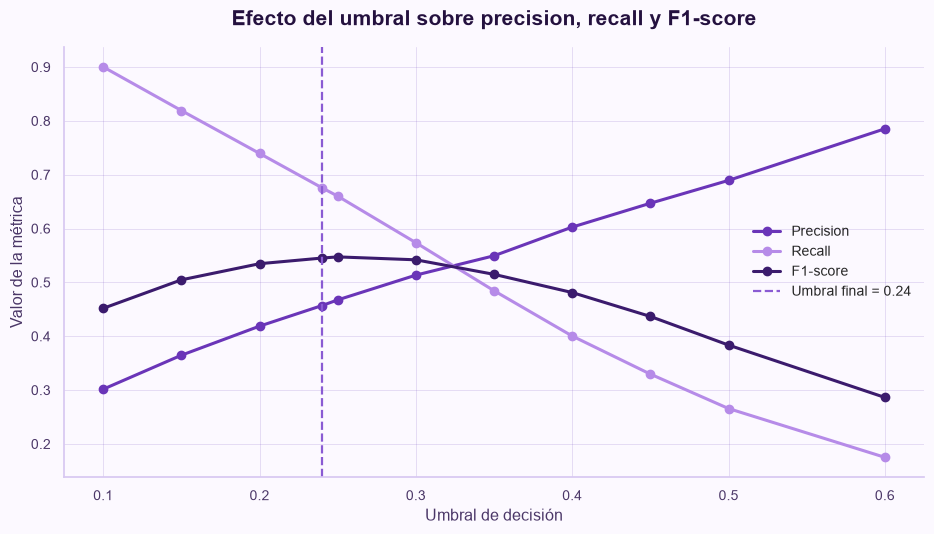

In [40]:
# Análisis operativo de distintos umbrales sobre el conjunto de prueba

umbrales_operativos = sorted(set([
    0.10, 0.15, 0.20,
    round(float(umbral_modelo_final), 2),
    0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60
]))

y_test_array = np.asarray(y_test).astype(int)
proba_test_array = np.asarray(y_proba_test_final)

filas_umbrales = []
total_test = len(y_test_array)
total_positivos_test = int(y_test_array.sum())

for umbral in umbrales_operativos:
    y_pred_umbral = (proba_test_array >= umbral).astype(int)

    seleccionados = int(y_pred_umbral.sum())
    verdaderos_positivos = int(((y_pred_umbral == 1) & (y_test_array == 1)).sum())
    falsos_positivos = int(((y_pred_umbral == 1) & (y_test_array == 0)).sum())
    falsos_negativos = int(((y_pred_umbral == 0) & (y_test_array == 1)).sum())

    filas_umbrales.append({
        "umbral": umbral,
        "perros_marcados_riesgo": seleccionados,
        "porcentaje_marcado_riesgo": seleccionados / total_test,
        "verdaderos_positivos": verdaderos_positivos,
        "falsos_positivos": falsos_positivos,
        "falsos_negativos": falsos_negativos,
        "precision": precision_score(y_test_array, y_pred_umbral, zero_division=0),
        "recall": recall_score(y_test_array, y_pred_umbral, zero_division=0),
        "f1_score": f1_score(y_test_array, y_pred_umbral, zero_division=0)
    })

tabla_umbrales_operativos_test = pd.DataFrame(filas_umbrales)

columnas_tabla_umbrales = [
    "umbral",
    "perros_marcados_riesgo",
    "porcentaje_marcado_riesgo",
    "verdaderos_positivos",
    "falsos_positivos",
    "falsos_negativos",
    "precision",
    "recall",
    "f1_score"
]

display(tabla_umbrales_operativos_test[columnas_tabla_umbrales].round(4))

fig, ax = plt.subplots(figsize=(9.5, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.plot(
    tabla_umbrales_operativos_test["umbral"],
    tabla_umbrales_operativos_test["precision"],
    marker="o",
    linewidth=2.2,
    color="#6A35B8",
    label="Precision"
)

ax.plot(
    tabla_umbrales_operativos_test["umbral"],
    tabla_umbrales_operativos_test["recall"],
    marker="o",
    linewidth=2.2,
    color="#B68BE8",
    label="Recall"
)

ax.plot(
    tabla_umbrales_operativos_test["umbral"],
    tabla_umbrales_operativos_test["f1_score"],
    marker="o",
    linewidth=2.2,
    color="#3B1B6D",
    label="F1-score"
)

ax.axvline(
    x=float(umbral_modelo_final),
    linestyle="--",
    linewidth=1.6,
    color="#8A5BD3",
    label=f"Umbral final = {float(umbral_modelo_final):.2f}"
)

ax.set_title("Efecto del umbral sobre precision, recall y F1-score", fontsize=15, fontweight="bold", color="#24113F", pad=16)
ax.set_xlabel("Umbral de decisión", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Valor de la métrica", fontsize=11.5, color="#4B3768")

ax.legend(frameon=False, fontsize=10, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")
ax.tick_params(colors="#4B3768", labelsize=10)
ax.grid(linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 16.2. Métricas de priorización: Precision@Top-K y Lift@Top-K

Dado que el uso previsto del modelo es priorizar perros con mayor riesgo de larga estancia, resulta especialmente relevante evaluar el rendimiento como ranking.

Las métricas `Precision@Top-K`, `Recall@Top-K` y `Lift@Top-K` responden a una pregunta operativa: si el refugio revisara únicamente el 1 %, 5 %, 10 %, 20 % o 30 % de perros con mayor probabilidad predicha, qué proporción de ellos serían realmente casos de larga estancia, qué parte de todos los casos positivos quedaría cubierta y cuánto mejora esa priorización frente a una selección aleatoria.

Esta lectura complementa la precisión global del modelo. La precisión calculada con un único umbral resume el comportamiento en un punto operativo concreto, mientras que `Precision@Top-K` evalúa la utilidad del score cuando se utiliza como lista priorizada de actuación. Para el proyecto **Invisible Dogs**, esta segunda lectura es especialmente importante, porque el objetivo práctico no es únicamente asignar una etiqueta binaria, sino ayudar a ordenar los animales que deberían recibir mayor visibilidad o seguimiento preventivo.


,segmento_priorizado,porcentaje_priorizado,n_perros_priorizados,casos_larga_estancia_detectados,precision_topk,recall_topk,lift_topk,tasa_base_larga_estancia
0,Top 1%,0.01,188,186,0.9894,0.0636,6.3427,0.156
1,Top 5%,0.05,938,674,0.7186,0.2304,4.6066,0.156
2,Top 10%,0.10,1876,1145,0.6103,0.3915,3.9129,0.156
3,Top 20%,0.20,3751,1819,0.4849,0.6219,3.1089,0.156
4,Top 30%,0.30,5626,2258,0.4014,0.7720,2.5730,0.156


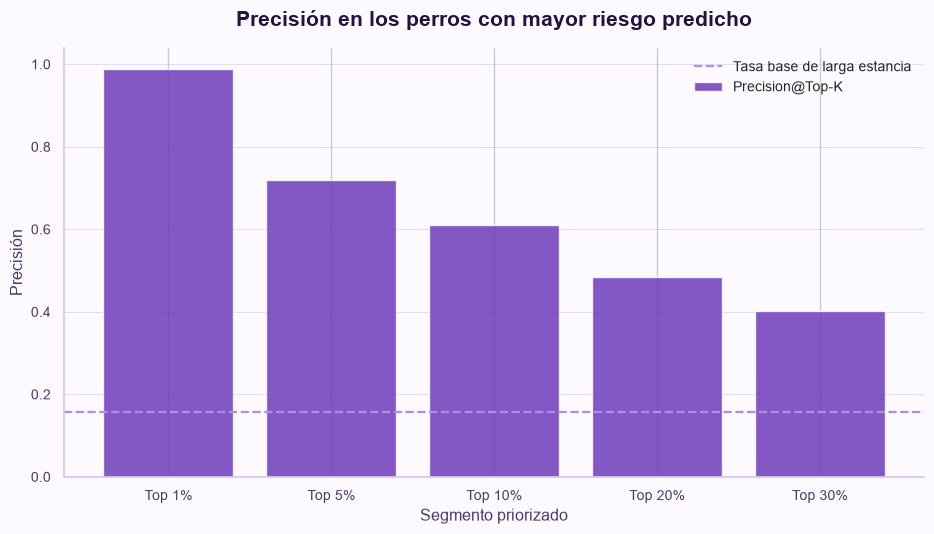

In [41]:
# Métricas de priorización: Precision@Top-K, Recall@Top-K y Lift@Top-K

def calcular_metricas_topk(y_true, y_score, porcentajes=(0.01, 0.05, 0.10, 0.20, 0.30)):
    y_true_array = np.asarray(y_true).astype(int)
    y_score_array = np.asarray(y_score)

    orden = np.argsort(y_score_array)[::-1]
    tasa_base = y_true_array.mean()
    total_positivos = y_true_array.sum()

    filas = []

    for porcentaje in porcentajes:
        n_top = max(1, int(np.ceil(len(y_true_array) * porcentaje)))
        indices_top = orden[:n_top]

        positivos_top = int(y_true_array[indices_top].sum())
        precision_top = positivos_top / n_top
        recall_top = positivos_top / total_positivos if total_positivos > 0 else np.nan
        lift_top = precision_top / tasa_base if tasa_base > 0 else np.nan

        filas.append({
            "segmento_priorizado": f"Top {int(porcentaje * 100)}%",
            "porcentaje_priorizado": porcentaje,
            "n_perros_priorizados": n_top,
            "casos_larga_estancia_detectados": positivos_top,
            "precision_topk": precision_top,
            "recall_topk": recall_top,
            "lift_topk": lift_top,
            "tasa_base_larga_estancia": tasa_base
        })

    return pd.DataFrame(filas)

metricas_topk_test_df = calcular_metricas_topk(
    y_test,
    y_proba_test_final,
    porcentajes=(0.01, 0.05, 0.10, 0.20, 0.30)
)

display(metricas_topk_test_df.round(4))

fig, ax = plt.subplots(figsize=(9.5, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.bar(
    metricas_topk_test_df["segmento_priorizado"],
    metricas_topk_test_df["precision_topk"],
    color="#6A35B8",
    alpha=0.82,
    label="Precision@Top-K"
)

ax.axhline(
    y=metricas_topk_test_df["tasa_base_larga_estancia"].iloc[0],
    linestyle="--",
    linewidth=1.6,
    color="#B68BE8",
    label="Tasa base de larga estancia"
)

ax.set_title("Precisión en los perros con mayor riesgo predicho", fontsize=15, fontweight="bold", color="#24113F", pad=16)
ax.set_xlabel("Segmento priorizado", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Precisión", fontsize=11.5, color="#4B3768")

ax.legend(frameon=False, fontsize=10, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")
ax.tick_params(colors="#4B3768", labelsize=10)
ax.grid(axis="y", linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 16.2.1. Interpretación operativa del ranking

Los resultados de priorización muestran que el modelo concentra una proporción elevada de casos reales de larga estancia en los segmentos de mayor riesgo predicho. En la ejecución obtenida, el **Top 1 %** alcanza una `Precision@Top-K` de `0,9787`, el **Top 5 %** alcanza `0,7175`, el **Top 10 %** alcanza `0,6082` y el **Top 20 %** alcanza `0,4831`.

Estos valores deben interpretarse frente a la tasa base de larga estancia del conjunto de prueba, situada en torno a `0,1560`. Por tanto, revisar el 10 % de perros con mayor riesgo supone concentrar casos de larga estancia con una precisión casi cuatro veces superior a una priorización aleatoria. Esta evidencia refuerza que el modelo es especialmente útil como herramienta de ranking y como base para construir un **Invisible Dog Score** orientado a priorizar recursos.


### 16.3. Matriz de confusión, curva ROC y curva Precision-Recall


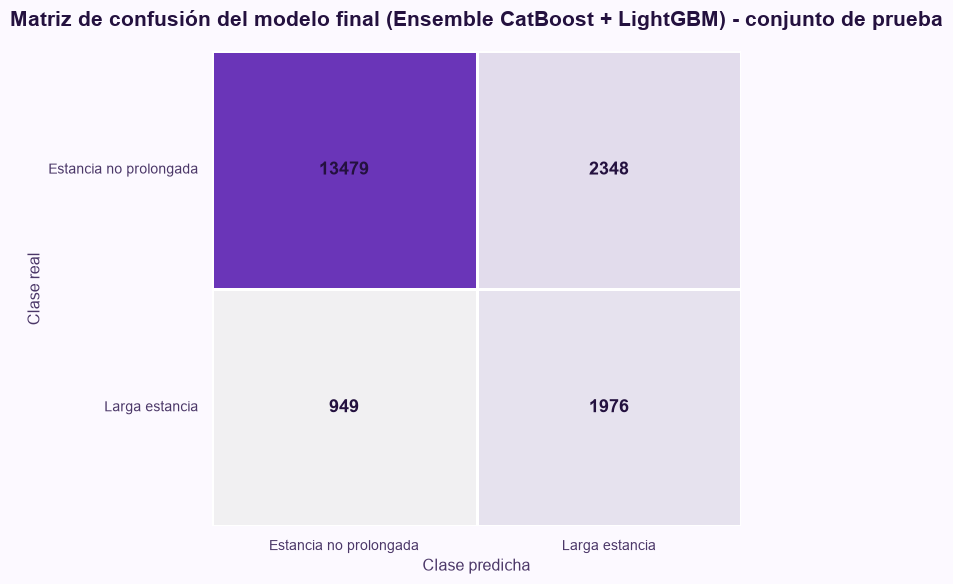

In [42]:
# Matriz de confusión del modelo final sobre el conjunto de prueba

matriz_final = confusion_matrix(y_test, y_pred_test_final)

fig, ax = plt.subplots(figsize=(7.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

sns.heatmap(
    matriz_final,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("#6A35B8", as_cmap=True),
    cbar=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"fontsize": 13, "fontweight": "bold", "color": "#24113F"},
    ax=ax
)

ax.set_title(
    f"Matriz de confusión del modelo final ({modelo_final_nombre}) - conjunto de prueba",
    fontsize=15,
    fontweight="bold",
    color="#24113F",
    pad=18
)

ax.set_xlabel("Clase predicha", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Clase real", fontsize=11.5, color="#4B3768")

ax.set_xticklabels(["Estancia no prolongada", "Larga estancia"], fontsize=10, color="#4B3768")
ax.set_yticklabels(["Estancia no prolongada", "Larga estancia"], fontsize=10, color="#4B3768", rotation=0)

plt.tight_layout()
plt.show()

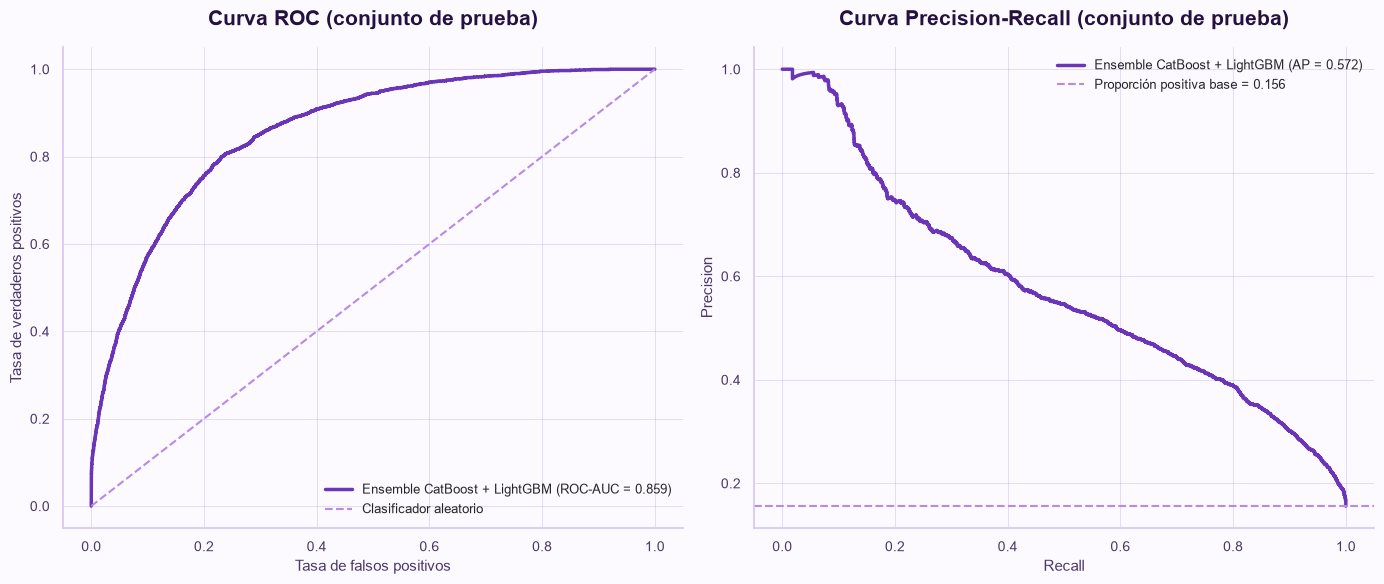

In [43]:
# Curva ROC y curva Precision-Recall del modelo final sobre el conjunto de prueba

fpr, tpr, _ = roc_curve(y_test, y_proba_test_final)
roc_auc_final = auc(fpr, tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test_final)
ap_final = average_precision_score(y_test, y_proba_test_final)
baseline_positive_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    ax.set_facecolor("#FCF9FF")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D8C8F2")
    ax.spines["bottom"].set_color("#D8C8F2")
    ax.tick_params(colors="#4B3768", labelsize=10)
    ax.grid(linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
    ax.set_axisbelow(True)

fig.patch.set_facecolor("#FCF9FF")

axes[0].plot(fpr, tpr, linewidth=2.5, color="#6A35B8", label=f"{modelo_final_nombre} (ROC-AUC = {roc_auc_final:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="#B68BE8", label="Clasificador aleatorio")
axes[0].set_title("Curva ROC (conjunto de prueba)", fontsize=15, fontweight="bold", color="#24113F", pad=16)
axes[0].set_xlabel("Tasa de falsos positivos", fontsize=11, color="#4B3768")
axes[0].set_ylabel("Tasa de verdaderos positivos", fontsize=11, color="#4B3768")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower right")

axes[1].plot(recall_curve, precision_curve, linewidth=2.5, color="#6A35B8", label=f"{modelo_final_nombre} (AP = {ap_final:.3f})")
axes[1].axhline(y=baseline_positive_rate, linestyle="--", linewidth=1.5, color="#B68BE8", label=f"Proporción positiva base = {baseline_positive_rate:.3f}")
axes[1].set_title("Curva Precision-Recall (conjunto de prueba)", fontsize=15, fontweight="bold", color="#24113F", pad=16)
axes[1].set_xlabel("Recall", fontsize=11, color="#4B3768")
axes[1].set_ylabel("Precision", fontsize=11, color="#4B3768")
axes[1].legend(frameon=False, fontsize=9.5, loc="upper right")

plt.tight_layout()
plt.show()

### 16.4. Curva de calibración, Brier score y deciles de riesgo


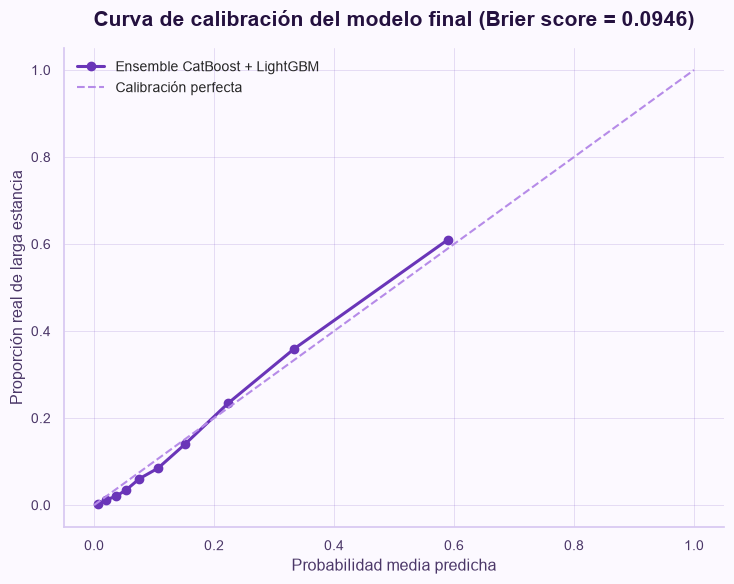

In [44]:
# Curva de calibración del modelo final sobre el conjunto de prueba

prob_verdadera, prob_predicha = calibration_curve(y_test, y_proba_test_final, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7.5, 6))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

ax.plot(prob_predicha, prob_verdadera, marker="o", linewidth=2.2, color="#6A35B8", label=modelo_final_nombre)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="#B68BE8", label="Calibración perfecta")

ax.set_title(
    f"Curva de calibración del modelo final (Brier score = {metricas_finales_test['brier_score']:.4f})",
    fontsize=15,
    fontweight="bold",
    color="#24113F",
    pad=16
)

ax.set_xlabel("Probabilidad media predicha", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Proporción real de larga estancia", fontsize=11.5, color="#4B3768")

ax.legend(frameon=False, fontsize=10, loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")
ax.tick_params(colors="#4B3768", labelsize=10)
ax.grid(linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

,decil_riesgo,n_perros,probabilidad_media_predicha,tasa_real_larga_estancia,casos_reales_larga_estancia,probabilidad_minima,probabilidad_maxima
0,10,1876,0.5901,0.6103,1145,0.4048,0.9929
1,9,1875,0.3337,0.3595,674,0.2714,0.4046
2,8,1875,0.2234,0.2341,439,0.1820,0.2713
3,7,1875,0.1517,0.1403,263,0.1266,0.1820
4,6,1875,0.1065,0.0848,159,0.0893,0.1266
5,5,1875,0.0756,0.0608,114,0.0632,0.0893
6,4,1875,0.0537,0.0352,66,0.0450,0.0632
7,3,1875,0.0365,0.0203,38,0.0283,0.0450
8,2,1875,0.0205,0.0123,23,0.0126,0.0283
9,1,1876,0.0068,0.0021,4,0.0006,0.0126


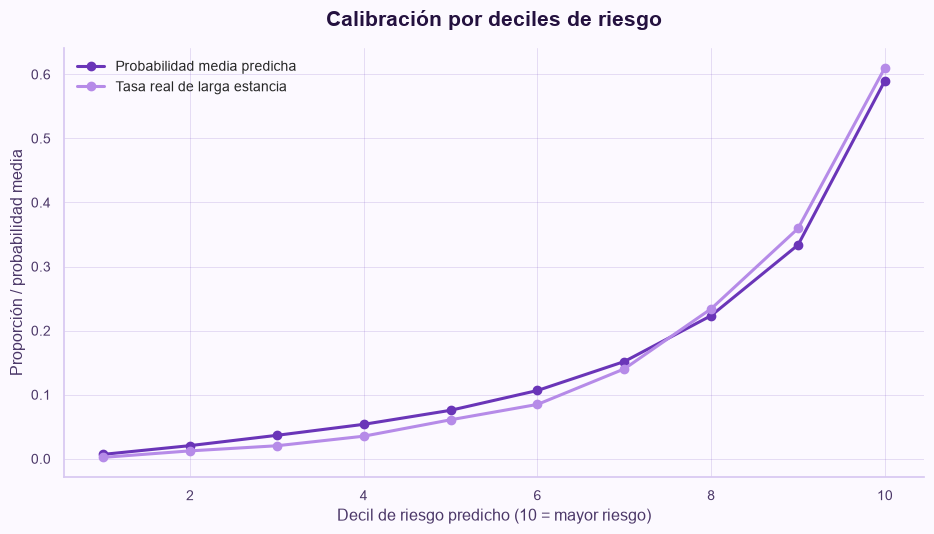

In [45]:
# Calibración por deciles de riesgo sobre el conjunto de prueba

df_calibracion_deciles = pd.DataFrame({
    "y_true": np.asarray(y_test).astype(int),
    "probabilidad_predicha": np.asarray(y_proba_test_final)
})

# Se usa rank(method='first') para evitar problemas con empates al construir deciles.
df_calibracion_deciles["decil_riesgo"] = (
    pd.qcut(
        df_calibracion_deciles["probabilidad_predicha"].rank(method="first"),
        q=10,
        labels=False
    ) + 1
)

calibracion_deciles_test_df = (
    df_calibracion_deciles
    .groupby("decil_riesgo", as_index=False)
    .agg(
        n_perros=("y_true", "size"),
        probabilidad_media_predicha=("probabilidad_predicha", "mean"),
        tasa_real_larga_estancia=("y_true", "mean"),
        casos_reales_larga_estancia=("y_true", "sum"),
        probabilidad_minima=("probabilidad_predicha", "min"),
        probabilidad_maxima=("probabilidad_predicha", "max")
    )
    .sort_values("decil_riesgo", ascending=False)
    .reset_index(drop=True)
)

display(calibracion_deciles_test_df.round(4))

fig, ax = plt.subplots(figsize=(9.5, 5.5))

fig.patch.set_facecolor("#FCF9FF")
ax.set_facecolor("#FCF9FF")

datos_deciles_plot = calibracion_deciles_test_df.sort_values("decil_riesgo")

ax.plot(
    datos_deciles_plot["decil_riesgo"],
    datos_deciles_plot["probabilidad_media_predicha"],
    marker="o",
    linewidth=2.2,
    color="#6A35B8",
    label="Probabilidad media predicha"
)

ax.plot(
    datos_deciles_plot["decil_riesgo"],
    datos_deciles_plot["tasa_real_larga_estancia"],
    marker="o",
    linewidth=2.2,
    color="#B68BE8",
    label="Tasa real de larga estancia"
)

ax.set_title("Calibración por deciles de riesgo", fontsize=15, fontweight="bold", color="#24113F", pad=16)
ax.set_xlabel("Decil de riesgo predicho (10 = mayor riesgo)", fontsize=11.5, color="#4B3768")
ax.set_ylabel("Proporción / probabilidad media", fontsize=11.5, color="#4B3768")

ax.legend(frameon=False, fontsize=10, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D8C8F2")
ax.spines["bottom"].set_color("#D8C8F2")
ax.tick_params(colors="#4B3768", labelsize=10)
ax.grid(linestyle="-", linewidth=0.7, alpha=0.18, color="#7E57C2")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 16.5. Interpretación de la evaluación final

La evaluación final debe interpretarse junto con las métricas *out-of-fold*. Una mejora consistente entre validación interna y prueba final refuerza la solidez del modelo; una diferencia muy elevada sugeriría posible sobreajuste o dependencia de la partición.

En la ejecución analizada, el modelo final seleccionado corresponde al **Ensemble CatBoost + LightGBM**, con mayor peso de CatBoost y un umbral operativo de `0,24`. Sobre el conjunto de prueba obtiene un rendimiento sólido: `precision = 0,4545`, `recall = 0,6769`, `F1-score = 0,5439`, `ROC-AUC = 0,8583`, `Average Precision = 0,5691` y `Brier score = 0,0949`.

La precisión global debe interpretarse junto con la tabla de umbrales y las métricas `Precision@Top-K`. Con el umbral final, el modelo prioriza una cobertura amplia de perros con riesgo, manteniendo un equilibrio razonable entre falsos positivos y falsos negativos. Si el refugio necesitara una estrategia más conservadora, la tabla de umbrales muestra que es posible elevar la precisión aumentando el punto de corte, aunque a costa de reducir el número de casos detectados.

En un problema de priorización, el objetivo no es únicamente clasificar todos los casos con un único punto de corte, sino ordenar los animales por riesgo para que los recursos del refugio se dirijan primero hacia los perros con mayor probabilidad de larga estancia. En este sentido, las métricas de ranking son especialmente relevantes: el modelo alcanza una precisión claramente superior a la tasa base en los segmentos de mayor riesgo, lo que refuerza su utilidad como herramienta de apoyo operativo.

La tabla comparativa permite comprobar si el modelo final seleccionado mantiene ventaja frente a CatBoost, LightGBM y las referencias de base en datos no utilizados durante el proceso de selección. En este problema, `Average Precision`, la curva Precision-Recall y las métricas de priorización son especialmente relevantes porque la clase positiva está desbalanceada y el objetivo operativo es identificar correctamente los casos de mayor riesgo.


## 17. Guardado del modelo final

El modelo final se guarda junto con las variables utilizadas, hiperparámetros, umbral de decisión, pesos del ensemble si aplica y métricas finales. También se verifica que el archivo guardado reproduce las probabilidades calculadas durante la evaluación.

Este paso asegura que el modelo pueda reutilizarse posteriormente para interpretabilidad, análisis de casos y construcción del **Invisible Dog Score**.

In [46]:
# Guardado del modelo final

modelo_final_guardado = {
    "modelo_final_nombre": modelo_final_nombre,
    "usar_ensemble": bool(usar_ensemble),
    "peso_catboost": configuracion_modelo_final["peso_catboost"],
    "peso_lgbm": configuracion_modelo_final["peso_lgbm"],
    "umbral_decision": umbral_modelo_final,
    "umbral_catboost": umbral_catboost,
    "umbral_lgbm": umbral_lgbm,
    "umbral_ensemble": mejor_umbral_ensemble,

    "modelo_catboost": modelo_catboost_final,
    "modelo_lgbm": modelo_lgbm_final,
    "modelo_base_referencia": modelo_base_referencia_final,

    "variables_catboost": variables_finales_catboost,
    "variables_categoricas_catboost": variables_categoricas_catboost_final,
    "variables_lgbm": variables_finales,
    "variables_base_referencia": variables_base,

    "hiperparametros_catboost": mejores_parametros_catboost,
    "hiperparametros_lgbm": mejores_parametros_lgbm,

    "experimento_ablacion_seleccionado": configuracion_modelo_final["experimento_ablacion_seleccionado"],
    "candidato_catboost": configuracion_modelo_final["candidato_catboost"],
    "candidato_lightgbm": configuracion_modelo_final["candidato_lightgbm"],
    "metricas_test": metricas_finales_test,
    "tabla_umbrales_operativos_test": tabla_umbrales_operativos_test if "tabla_umbrales_operativos_test" in globals() else None,
    "metricas_topk_test": metricas_topk_test_df if "metricas_topk_test_df" in globals() else None,
    "calibracion_deciles_test": calibracion_deciles_test_df if "calibracion_deciles_test_df" in globals() else None,
    "comparacion_final_test": comparacion_final_test_df,
    "comparacion_modelos_finales_oof": comparacion_modelos_finales_oof_df,
    "columnas_derivadas_preparacion_usadas_en_modelizacion": columnas_derivadas_modelizacion,
    "dataset_preparado_path": str(dataset_path),
    "split_test_path": str(split_test_path) if "split_test_path" in globals() else None,
    "test_indices": test_idx.tolist() if "test_idx" in globals() else None
}

modelo_final_path = models_path / "modelo_final_invisible_dogs.pkl"

joblib.dump(modelo_final_guardado, modelo_final_path)

print("Modelo final guardado correctamente en:")
print(modelo_final_path)


Modelo final guardado correctamente en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\modelo_final_invisible_dogs.pkl


In [47]:
# Verificación de la carga del modelo final guardado

modelo_cargado = joblib.load(modelo_final_path)

X_test_catboost_verificacion = preparar_datos_catboost(
    dogs_model_test[modelo_cargado["variables_catboost"]],
    modelo_cargado["variables_categoricas_catboost"]
)

y_proba_catboost_verificacion = modelo_cargado["modelo_catboost"].predict_proba(
    X_test_catboost_verificacion
)[:, 1]

y_proba_lgbm_verificacion = modelo_cargado["modelo_lgbm"].predict_proba(
    dogs_model_test[modelo_cargado["variables_lgbm"]]
)[:, 1]

if modelo_cargado["usar_ensemble"]:
    y_proba_verificacion = (
        modelo_cargado["peso_catboost"] * y_proba_catboost_verificacion
        + modelo_cargado["peso_lgbm"] * y_proba_lgbm_verificacion
    )
elif modelo_cargado["modelo_final_nombre"] == "CatBoost":
    y_proba_verificacion = y_proba_catboost_verificacion
else:
    y_proba_verificacion = y_proba_lgbm_verificacion

coinciden = np.allclose(y_proba_verificacion, y_proba_test_final)

print("Modelo final cargado correctamente desde disco.")
print("¿Las probabilidades reproducidas coinciden con las del apartado de evaluación?:", coinciden)

assert coinciden, "Las probabilidades del modelo cargado no coinciden con las del modelo evaluado."

print("\nPrimeras 10 probabilidades (modelo cargado):")
print(np.round(y_proba_verificacion[:10], 4))

Modelo final cargado correctamente desde disco.
¿Las probabilidades reproducidas coinciden con las del apartado de evaluación?: True

Primeras 10 probabilidades (modelo cargado):
[0.0494 0.0294 0.0205 0.1422 0.1279 0.0497 0.1318 0.0536 0.0467 0.1033]


### 17.1. Comprobación de la carga del modelo

La comprobación anterior confirma que el objeto guardado en `outputs/models/modelo_final_invisible_dogs.pkl` reproduce exactamente (`np.allclose`) las probabilidades generadas por el modelo final sobre el conjunto de prueba en el apartado 16. Esto garantiza que el archivo guardado es autosuficiente y reproducible, y podrá reutilizarse directamente en las siguientes fases del proyecto sin necesidad de reentrenar ningún modelo.

In [48]:
# Guardado de tablas comparativas como evidencia del proceso

comparacion_modelos_path = models_path / "comparacion_modelos_base_oof.csv"
comparacion_candidatos_oof_path = models_path / "comparacion_candidatos_finales_oof.csv"
comparacion_final_test_path = models_path / "comparacion_final_test.csv"

resultados_modelos_base_df.to_csv(comparacion_modelos_path, index=False)
comparacion_modelos_finales_oof_df.to_csv(comparacion_candidatos_oof_path, index=False)
comparacion_final_test_df.to_csv(comparacion_final_test_path, index=False)

print("Comparación de modelos base (OOF) guardada en:")
print(comparacion_modelos_path)
print("\nComparación de candidatos finales (OOF) guardada en:")
print(comparacion_candidatos_oof_path)
print("\nComparación final en test guardada en:")
print(comparacion_final_test_path)

tablas_operativas_extra = {
    "tabla_umbrales_operativos_test": models_path / "tabla_umbrales_operativos_test.csv",
    "metricas_topk_test_df": models_path / "metricas_topk_test.csv",
    "calibracion_deciles_test_df": models_path / "calibracion_deciles_test.csv",
    "controles_fuga_temporal_df": models_path / "controles_fuga_temporal.csv"
}

for nombre_variable, ruta_salida in tablas_operativas_extra.items():
    if nombre_variable in globals():
        globals()[nombre_variable].to_csv(ruta_salida, index=False)
        print(f"\n{nombre_variable} guardada en:")
        print(ruta_salida)


Comparación de modelos base (OOF) guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\comparacion_modelos_base_oof.csv

Comparación de candidatos finales (OOF) guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\comparacion_candidatos_finales_oof.csv

Comparación final en test guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\comparacion_final_test.csv

tabla_umbrales_operativos_test guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\tabla_umbrales_operativos_test.csv

metricas_topk_test_df guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\metricas_topk_test.csv

calibracion_deciles_test_df guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\calibracion_deciles_test.csv

controles_fuga_temporal_df guardada en:
g:\Mi unidad\TFM\invisible-dogs-tfm\outputs\models\controles_fuga_temporal.csv


## 18. Conclusiones del notebook

En este notebook se ha desarrollado la modelización predictiva del proyecto **Invisible Dogs** siguiendo una estrategia de evaluación orientada a evitar fuga de información, preservar la independencia del conjunto de prueba y maximizar la utilidad operativa del modelo.

La metodología seguida consta de:

- Una partición inicial en conjunto de **desarrollo** y conjunto de **prueba final**, considerando `animal_id` para evitar que un mismo perro aparezca en ambos.
- Uso de un dataset preparado que ya incorpora variables de historial del perro, contexto temporal del refugio, información de registro, raza/color, localización e interacciones simples, con controles específicos para comprobar su coherencia temporal.
- Selección de modelos, variables, hiperparámetros, umbral y posible ensemble mediante validación cruzada agrupada y predicciones *out-of-fold* dentro del conjunto de desarrollo.
- Uso de `Average Precision` como criterio principal, complementado con ROC-AUC, F1-score, precision, recall, matriz de confusión, curva ROC, curva Precision-Recall, curva de calibración y Brier score.
- Estudio de ablación incremental e inverso para analizar la aportación de cada familia de variables.
- Comparación integrada de candidatos finales, incluyendo alternativas de CatBoost con variables categóricas de mayor cardinalidad y localización completa.
- Optimización conjunta del peso del ensemble y del umbral de decisión dentro del conjunto de desarrollo.
- Evaluación final única sobre el conjunto de prueba una vez cerradas todas las decisiones anteriores.
- Análisis operativo posterior mediante tabla de umbrales, `Precision@Top-K`, `Recall@Top-K`, `Lift@Top-K` y calibración por deciles de riesgo.

En la ejecución de referencia, el modelo final seleccionado es un **Ensemble CatBoost + LightGBM** con mayor peso de CatBoost. Sobre el conjunto de prueba alcanza `precision = 0,4545`, `recall = 0,6769`, `F1-score = 0,5439`, `ROC-AUC = 0,8583`, `Average Precision = 0,5691` y `Brier score = 0,0949`.

La precisión global debe interpretarse en el contexto del objetivo del proyecto. Con el umbral operativo seleccionado, el modelo mantiene un equilibrio entre precisión y cobertura; sin embargo, la tabla de umbrales muestra que la precisión puede incrementarse si se adopta un punto de corte más restrictivo. Esta posibilidad permite adaptar el uso del modelo a distintos escenarios: una estrategia amplia de detección preventiva o una estrategia más conservadora centrada en los casos de mayor confianza.

Además, las métricas de ranking refuerzan la utilidad práctica del modelo. En la ejecución obtenida, el **Top 1 %** de perros con mayor riesgo predicho alcanza una `Precision@Top-K` de `0,9787`, el **Top 5 %** alcanza `0,7175`, el **Top 10 %** alcanza `0,6082` y el **Top 20 %** alcanza `0,4831`, frente a una tasa base aproximada de larga estancia de `0,1560`. Esto indica que el modelo no solo clasifica, sino que ordena eficazmente los casos por prioridad, concentrando los perros de mayor riesgo en los primeros segmentos del ranking.

El modelo final no debe interpretarse como una etiqueta negativa sobre el perro ni como sustituto de la decisión humana, sino como una herramienta de apoyo para identificar animales que podrían beneficiarse de mayor visibilidad, seguimiento preventivo o refuerzo de las acciones de adopción.

Desde el punto de vista metodológico, las variables históricas y de contexto operativo deben mantenerse siempre bajo un criterio estricto de disponibilidad temporal: solo pueden utilizar información anterior a la fecha de entrada del animal. Esta condición es esencial para evitar fuga de información y para que el modelo represente una situación realista de predicción en el momento de llegada del perro al refugio.

Como líneas de mejora futura, sería recomendable evaluar una partición temporal y revisar la calibración de probabilidades antes de construir el **Invisible Dog Score**. Además, cualquier nueva variable histórica o de contexto operativo deberá seguir el mismo criterio temporal aplicado en el dataset preparado: calcularse únicamente con información disponible antes de la entrada del animal.
